In [1]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  04_qb_modeling.ipynb                                            ║
# ║  XGBoost QB Model — Training, Evaluation, and Analysis          ║
# ╚══════════════════════════════════════════════════════════════════╝

# ─── 0. Imports & Setup ─────────────────────────────────────────────
"""
Standard imports, path setup, logging configuration
"""

import pandas as pd
import matplotlib.pyplot as plt
import sys
from pathlib import Path
import logging

# Path setup so src modules are importable from notebook
sys.path.append(str(Path.cwd().parent.parent))

from src import configurations as cfg
from src.models.models import QBXGBoostModel
from src.models.base_models import RidgeRegressionModel
from src.models.trainer import(
    train_and_evaluate,
    time_series_split, 
    prepare_features,
)
from src.evaluation.metrics import(
    evaluate, 
    compare_models, 
    baseline_improvement, 
    prediction_summary,
)

# Setup logging
logger = logging.getLogger(__name__)
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")

In [2]:
# ─── 1. Load Data ───────────────────────────────────────────────────
"""
Load qb_features_2018_2025.csv and perform basic sanity checks on shape and null values
"""

# Load the dataset
df_features = pd.read_csv(
    Path.cwd().parent.parent / "src" / "data" / 
    cfg.QB_OUTPUT_FEATURES_FILE.replace("{start}", "2018").replace("{end}", "2025")
)

# Shape and null check
logger.info(f"Dataset shape: {df_features.shape}")

for col in df_features.columns:
    null_count = df_features[col].isnull().sum()
    if null_count > 0:
        logger.info(f"Column '{col}' has {null_count} null values.")

2026-06-29 20:56:22,177 - INFO - Dataset shape: (278, 147)
2026-06-29 20:56:22,183 - INFO - Column 'qbr' has 1 null values.


In [3]:
# ─── 2. Train/Test Split ────────────────────────────────────────────
"""
Same split as baseline notebook
"""

# Perform manual split
df_train = df_features[(df_features['season'] <= 2022)]
df_test_xgboost = df_features[df_features['season'] == 2024]

# Print row counts for train and test to confirm
logger.info(f"Train rows: {df_train.shape[0]}")
logger.info(f"Test rows: {df_test_xgboost.shape[0]}")

2026-06-29 20:56:22,223 - INFO - Train rows: 203
2026-06-29 20:56:22,224 - INFO - Test rows: 37


2026-06-29 20:56:22,257 - INFO - Ridge CV Summary:
2026-06-29 20:56:22,263 - INFO - Target: target_yds | Best alpha: 1.0 | CV mean R²: 0.2269
2026-06-29 20:56:22,265 - INFO - Target: target_yds | Best alpha: 1.0 | CV mean RMSE: 1139.9614
2026-06-29 20:56:22,268 - INFO - Target: target_td | Best alpha: 100.0 | CV mean R²: 0.2868
2026-06-29 20:56:22,269 - INFO - Target: target_td | Best alpha: 100.0 | CV mean RMSE: 8.7577
2026-06-29 20:56:22,272 - INFO - Target: target_int | Best alpha: 1000.0 | CV mean R²: 0.1042
2026-06-29 20:56:22,274 - INFO - Target: target_int | Best alpha: 1000.0 | CV mean RMSE: 3.7899
2026-06-29 20:56:22,276 - INFO - Target: target_att | Best alpha: 10.0 | CV mean R²: 0.2507
2026-06-29 20:56:22,278 - INFO - Target: target_att | Best alpha: 10.0 | CV mean RMSE: 146.8186


2026-06-29 20:56:22,280 - INFO - Target: target_cmp | Best alpha: 10.0 | CV mean R²: 0.2365
2026-06-29 20:56:22,281 - INFO - Target: target_cmp | Best alpha: 10.0 | CV mean RMSE: 96.6930
2026-06-29 20:56:22,282 - INFO - Target: target_g | Best alpha: 100.0 | CV mean R²: 0.2331
2026-06-29 20:56:22,285 - INFO - Target: target_g | Best alpha: 100.0 | CV mean RMSE: 3.9558


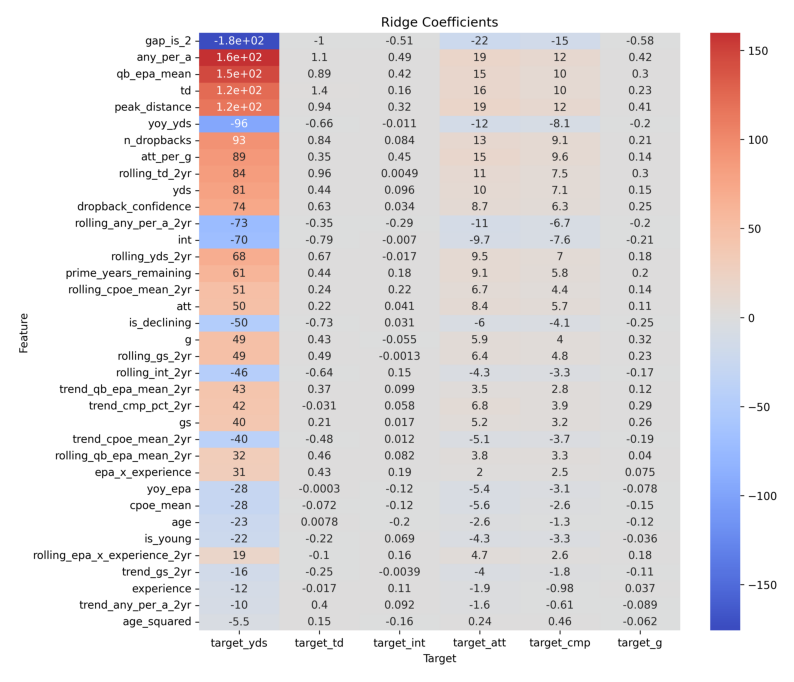

In [4]:
# ─── 3. Baseline Comparison Reference ───────────────────────────────
"""
Load saved Ridge experiment results for comparison
"""

# Load Ridge results
ridge_results = pd.read_csv(
    Path.cwd().parent.parent / "src" / "data" / "processed" / "base_models" / "qb" / cfg.QB_RIDGE_SENSITIVITY
)

# Print per-alpha per-target Ridge CV summary
logger.info("Ridge CV Summary:")
for target in cfg.QB_TARGET_COLS.values():
    target_results = ridge_results[ridge_results['target'] == target]
    best_alpha__r2_row = target_results.loc[target_results['r2'].idxmax()]
    logger.info(f"Target: {target} | Best alpha: {best_alpha__r2_row['alpha']} | CV mean R²: {best_alpha__r2_row['r2']:.4f}")

    best_alpha__rmse_row = target_results.loc[target_results['rmse'].idxmin()]
    logger.info(f"Target: {target} | Best alpha: {best_alpha__rmse_row['alpha']} | CV mean RMSE: {best_alpha__rmse_row['rmse']:.4f}")

# Display Ridge coefficients PNG for reference
ridge_coeffs_path = Path.cwd().parent.parent / "src" / "data" / "processed" / "base_models" / "qb" / cfg.QB_RIDGE_COEFFS
if ridge_coeffs_path.exists():
    img = plt.imread(ridge_coeffs_path)
    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    plt.axis('off')
    plt.show()


In [5]:
# ─── 4. Initial XGBoost Training ────────────────────────────────────
"""
Train and evaluate QBXGBoostModel
"""

target_cols = list(cfg.QB_TARGET_COLS.values())

model_kwargs = {
    "target_cols": target_cols,
    "feature_cols": cfg.QB_FEATURE_COLS,
    **cfg.QB_MODEL_PARAMS,
    "target_params": cfg.QB_TARGET_MODEL_PARAMS,
    "target_feature_cols": cfg.QB_TARGET_FEATURE_COLS,
}

# Train and evaluate
results = train_and_evaluate(
    df=df_features,
    model_class=QBXGBoostModel,
    model_kwargs=model_kwargs,
    feature_cols=cfg.QB_FEATURE_COLS,
    target_cols=target_cols,
    test_season=2024,
    n_cv_splits=3,
    apply_constraints=True,
    save_model=True,
    model_name="qb_xgboost",
    season_col="season",
    constraints=cfg.QB_PHYSICAL_CONSTRAINTS,
)

# Print CV summary
cv_results   = results["cv_results"]
cv_summary   = results["cv_summary"]
test_metrics = results["test_metrics"]
predictions_xgboost  = results["predictions"]
model: QBXGBoostModel = results["model"]

print("CV Summary:")
print(cv_summary.to_string())
print("\nTest Metrics:")
print(test_metrics.to_string())

2026-06-29 20:56:23,691 - INFO - Starting full training pipeline for model QBXGBoostModel with test season 2024 and CV folds 3...
2026-06-29 20:56:23,693 - INFO - Performing time series split with test season 2024...
2026-06-29 20:56:23,707 - INFO - Train: 2018-2023 (241 rows) | Test: 2024 (37 rows)
2026-06-29 20:56:23,708 - INFO - Running cross validation with 3 folds...
2026-06-29 20:56:23,710 - INFO - Generating 3 CV folds with expanding window split...
2026-06-29 20:56:23,718 - INFO - Fold 1: train 2018-2020 (114 rows) -> val 2021 (46 rows)
2026-06-29 20:56:23,723 - INFO - Fold 2: train 2018-2021 (160 rows) -> val 2022 (43 rows)
2026-06-29 20:56:23,728 - INFO - Fold 3: train 2018-2022 (203 rows) -> val 2023 (38 rows)
2026-06-29 20:56:23,729 - INFO - Fold 1: validating on season 2021...
2026-06-29 20:56:23,730 - INFO - Preparing features with median imputation...
2026-06-29 20:56:25,550 - INFO - Fitted XGBoost model for target target_yds on 114 rows
2026-06-29 20:56:25,600 - INFO - 

CV Summary:
       target    rmse_mean    rmse_std    mae_mean     mae_std   r2_mean    r2_std
5  target_yds  1070.265544  159.068909  880.733217  145.616106  0.391685  0.133361
0  target_att   147.892809   30.324310  119.322611   26.979312  0.305246  0.154087
1  target_cmp    95.811157   16.512022   77.865261   15.554890  0.381996  0.117993
4   target_td     9.121642    0.695268    7.329237    0.809348  0.275042  0.123724
2    target_g     4.001417    0.753125    3.409927    0.725893  0.249039  0.164886
3  target_int     3.511505    0.017602    2.874788    0.016770  0.216302  0.050691

Test Metrics:
       target         rmse         mae        r2
0  target_att   135.706049  106.488812  0.359849
1  target_cmp    94.313920   79.116435  0.273622
2    target_g     3.932057    3.299020  0.242224
3  target_int     3.680888    3.068371  0.154966
4   target_td     9.132309    7.202100  0.224535
5  target_yds  1089.045952  888.598032  0.294410


In [6]:
# ─── 5. CV Stability Check ──────────────────────────────────────────
"""
Print per-fold RMSE for each target.
"""

logger.info("Per-fold CV results:")

# Print per-fold CV results for each target
for target in target_cols:
    fold_results = cv_results[cv_results['target'] == target]
    logger.info(f"Target: {target}")

    for fold in sorted(fold_results['fold'].unique()):
        fold_row = fold_results[fold_results['fold'] == fold]
        rmse = fold_row['rmse'].values[0]
        r2 = fold_row['r2'].values[0]
        logger.info(f"  Fold {fold} | RMSE: {rmse:.4f} | R²: {r2:.4f}")

2026-06-29 20:56:27,044 - INFO - Per-fold CV results:
2026-06-29 20:56:27,047 - INFO - Target: target_yds
2026-06-29 20:56:27,050 - INFO -   Fold 1 | RMSE: 1226.2701 | R²: 0.2652
2026-06-29 20:56:27,053 - INFO -   Fold 2 | RMSE: 1076.2266 | R²: 0.3788
2026-06-29 20:56:27,055 - INFO -   Fold 3 | RMSE: 908.2999 | R²: 0.5310
2026-06-29 20:56:27,057 - INFO - Target: target_td
2026-06-29 20:56:27,059 - INFO -   Fold 1 | RMSE: 9.8968 | R²: 0.1565
2026-06-29 20:56:27,062 - INFO -   Fold 2 | RMSE: 8.9149 | R²: 0.2652
2026-06-29 20:56:27,064 - INFO -   Fold 3 | RMSE: 8.5532 | R²: 0.4034
2026-06-29 20:56:27,066 - INFO - Target: target_int
2026-06-29 20:56:27,069 - INFO -   Fold 1 | RMSE: 3.4920 | R²: 0.2063
2026-06-29 20:56:27,070 - INFO -   Fold 2 | RMSE: 3.5261 | R²: 0.2712
2026-06-29 20:56:27,074 - INFO -   Fold 3 | RMSE: 3.5165 | R²: 0.1714
2026-06-29 20:56:27,076 - INFO - Target: target_att
2026-06-29 20:56:27,079 - INFO -   Fold 1 | RMSE: 173.7187 | R²: 0.2170
2026-06-29 20:56:27,081 - INF

In [7]:
# ─── 6. Ridge vs XGBoost Comparison ─────────────────────────────────
"""
Use compare_models() and baseline_improvement() with all three models:
    persistence, ridge, xgboost

Key question: does XGBoost beat Ridge by a meaningful margin?
If improvement < 5% over Ridge, the non-linear signal is weak
and hyperparameter tuning may have diminishing returns.
"""

# Obtain Ridge test metrics for comparison
df_train, df_test_ridge = time_series_split(df_features, season_col="season", test_season=2024)
x_train, x_test, _ = prepare_features(df_train, df_test_ridge, feature_cols=cfg.QB_FEATURE_COLS)

# Model instantiation
ridge = RidgeRegressionModel(
    target_cols=list(cfg.QB_TARGET_COLS.values()),
    feature_cols=cfg.QB_FEATURE_COLS,
    alpha=cfg.ALPHA
)

# Fit on training set
ridge.fit(x_train.join(df_train[cfg.QB_TARGET_COLS.values()]))

# Generate predictions on test set
predictions_ridge = ridge.predict(x_test)

# Evaluate with evaluate()
df_metrics_ridge = evaluate(df_test_ridge, predictions_ridge, ridge.target_cols)

logger.info("Comparing Model Performance")

# Compare models
comparison_dict = {
    "ridge": df_metrics_ridge,
    "xgboost": test_metrics
}
df_comparison = compare_models(comparison_dict)

# Evaluate the improvement of xgboost over ridge
df_improvement = baseline_improvement(baseline_metrics=df_metrics_ridge, model_metrics=test_metrics)

logger.info("Model Comparison:")
print(df_comparison.to_string())
logger.info("\nBaseline Improvement:")
print(df_improvement.to_string())

2026-06-29 20:56:27,116 - INFO - Performing time series split with test season 2024...
2026-06-29 20:56:27,128 - INFO - Train: 2018-2023 (241 rows) | Test: 2024 (37 rows)
2026-06-29 20:56:27,129 - INFO - Preparing features with median imputation...
2026-06-29 20:56:27,183 - INFO - Comparing Model Performance
2026-06-29 20:56:27,208 - INFO - Model Comparison:
2026-06-29 20:56:27,216 - INFO - 
Baseline Improvement:


       target         rmse                                 mae                               r2                     
                     ridge      xgboost best_model       ridge     xgboost best_model     ridge   xgboost best_model
0  target_att   147.816575   135.706049    xgboost  123.927775  106.488812    xgboost  0.240495  0.359849    xgboost
1  target_cmp    97.332329    94.313920    xgboost   80.921407   79.116435    xgboost  0.226384  0.273622    xgboost
2    target_g     3.966871     3.932057    xgboost    3.466039    3.299020    xgboost  0.228746  0.242224    xgboost
3  target_int     3.905956     3.680888    xgboost    3.294730    3.068371    xgboost  0.048467  0.154966    xgboost
4   target_td     9.154581     9.132309    xgboost    7.125989    7.202100      ridge  0.220747  0.224535    xgboost
5  target_yds  1151.533268  1089.045952    xgboost  947.263118  888.598032    xgboost  0.211117  0.294410    xgboost
        target metric     baseline        model       improvemen

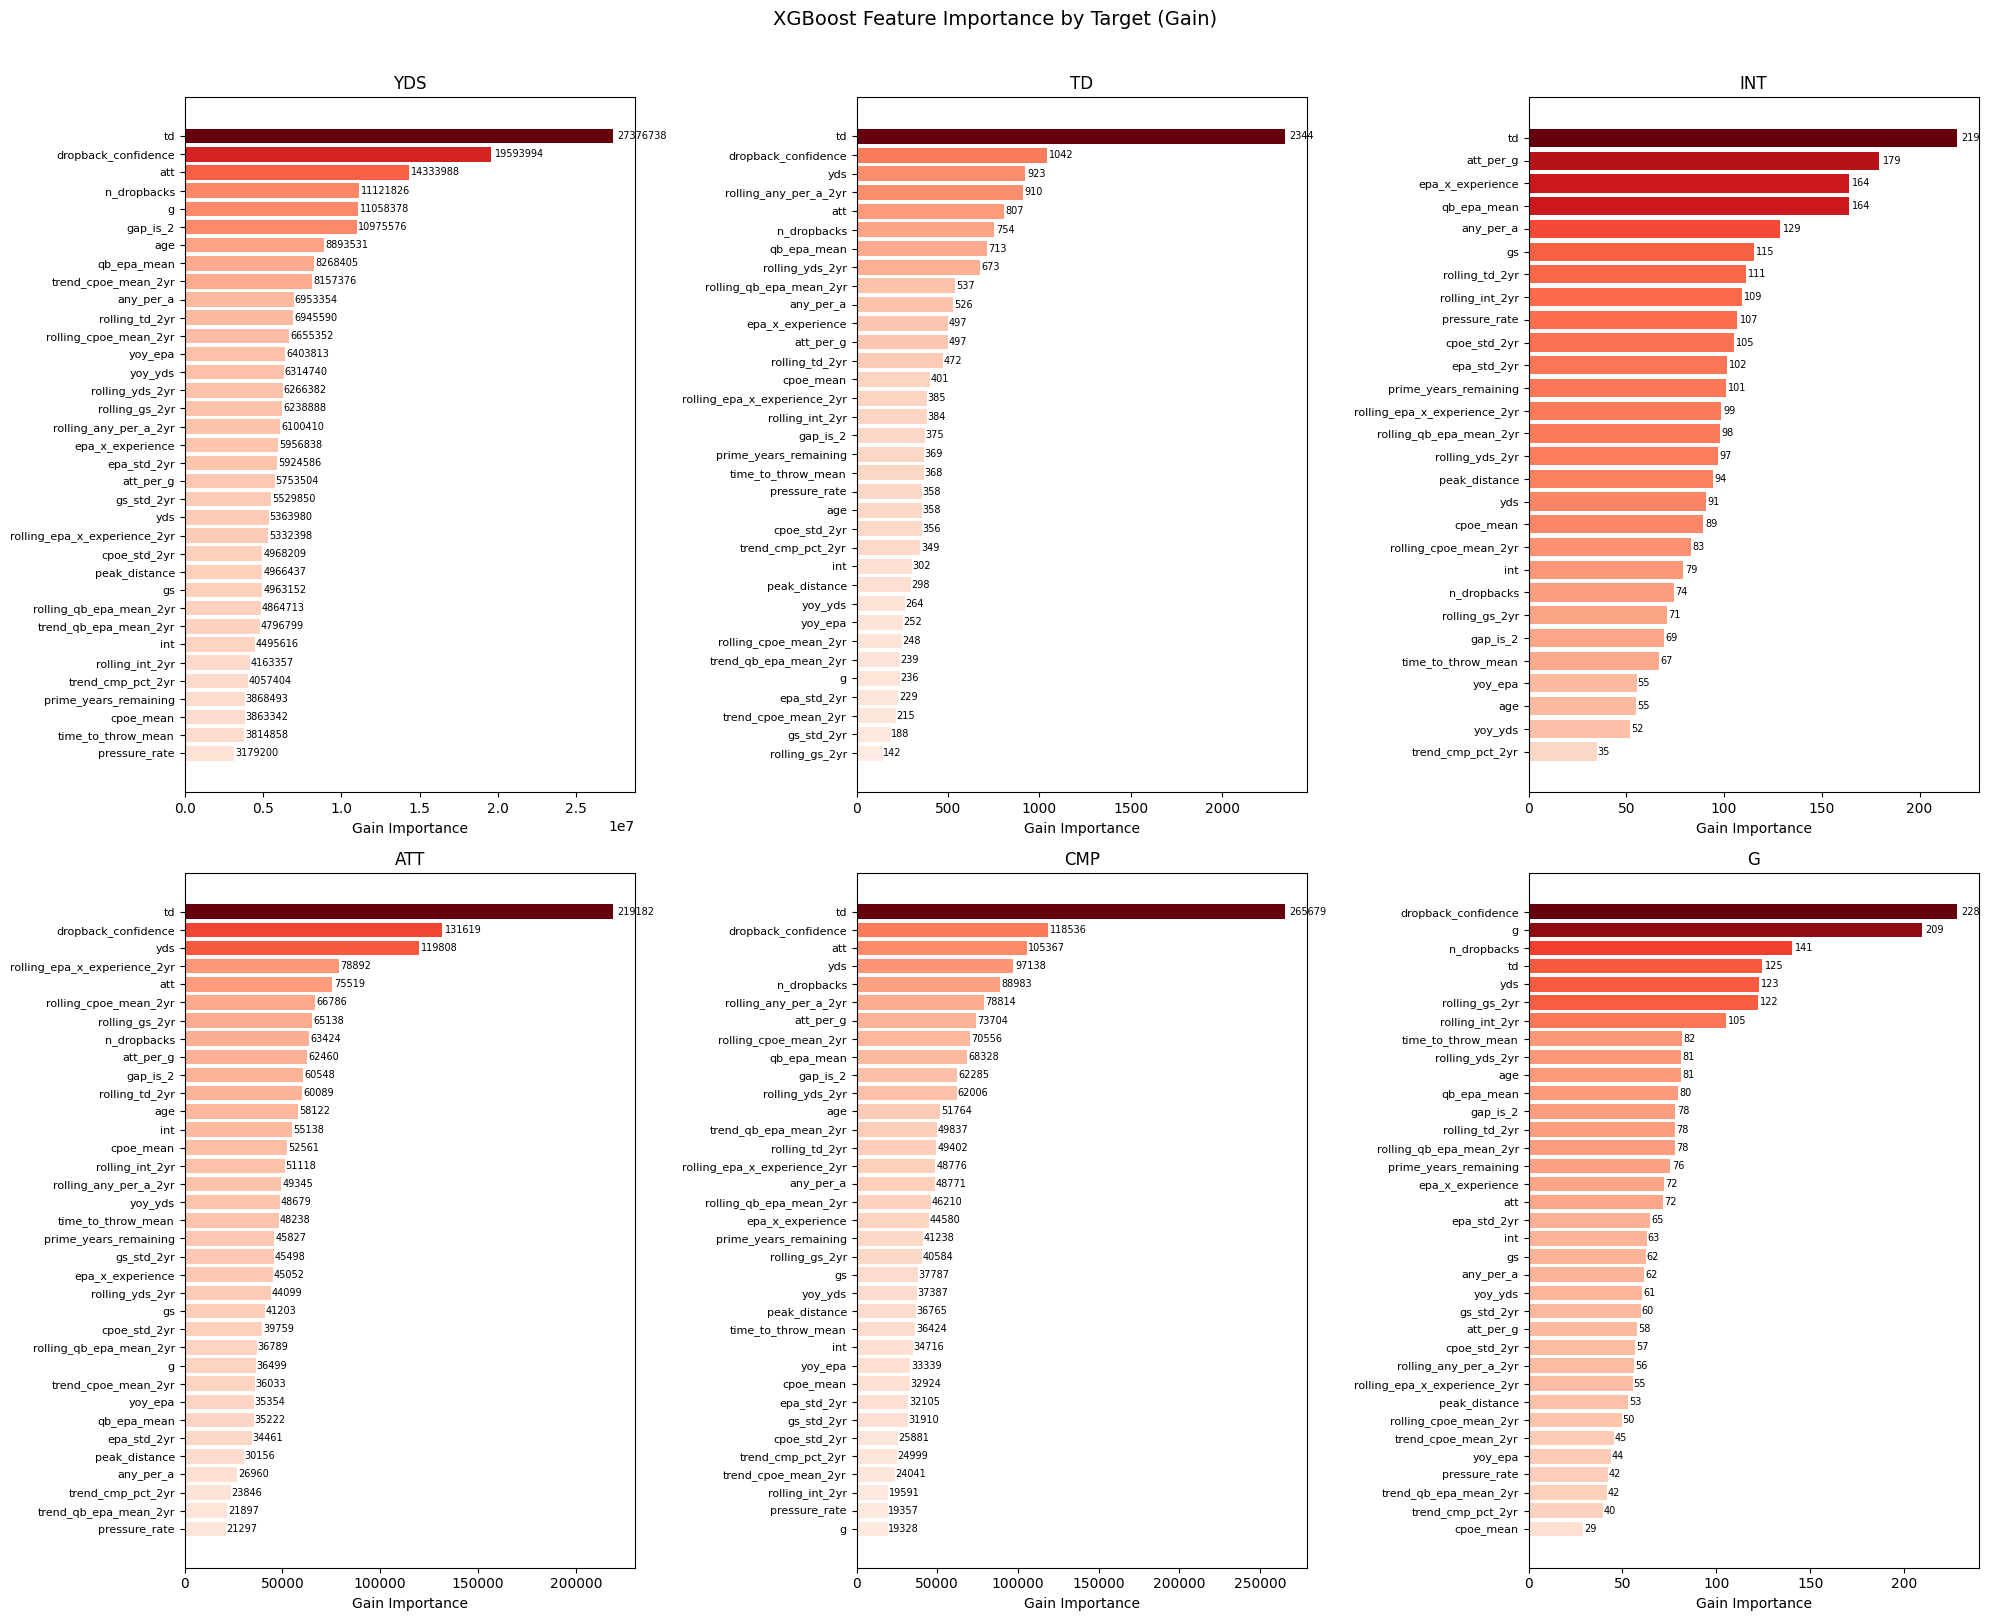

In [8]:
# ─── 7. Feature Importance Analysis ─────────────────────────────────
"""
Call get_feature_importance() — compare to Ridge coefficients
"""

# Extract feature importance from XGBoost model
df_importance = model.get_feature_importance()

fig, axes = plt.subplots(2, 3, figsize=(20, 16))
axes = axes.flatten()

for i, target_col in enumerate(model.target_cols):
    # Get only the features this target was trained on
    target_features = model.target_feature_cols.get(target_col, model.feature_cols)

    # Get importance for this target's features only, sorted descending
    target_importance = (
        df_importance.loc[target_features, target_col]
        .sort_values(ascending=True)
    )

    # Drop features with zero importance
    target_importance = target_importance[target_importance > 0]

    # Normalize to 0-1
    normalized = target_importance / target_importance.max() if target_importance.max() > 0 else target_importance
    colors     = plt.cm.Reds(normalized.values)

    axes[i].barh(target_importance.index, target_importance.values, color=colors)
    axes[i].set_title(target_col.replace("target_", "").upper(), fontsize=12)
    axes[i].set_xlabel("Gain Importance")
    axes[i].tick_params(axis="y", labelsize=8)

    for j, val in enumerate(target_importance.values):
        axes[i].text(val * 1.01, j, f"{val:.0f}", va="center", fontsize=7)

plt.suptitle("XGBoost Feature Importance by Target (Gain)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

2026-06-29 20:56:29,536 - INFO - Generating SHAP summary plot for target: target_yds


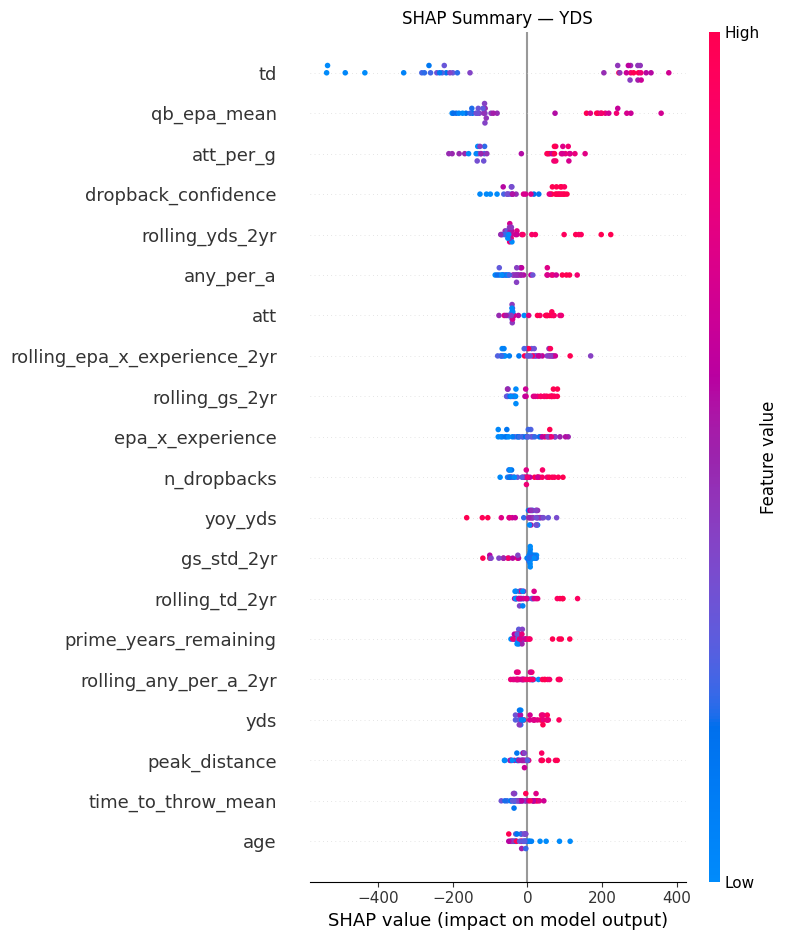

2026-06-29 20:56:30,166 - INFO - Generating SHAP summary plot for target: target_td


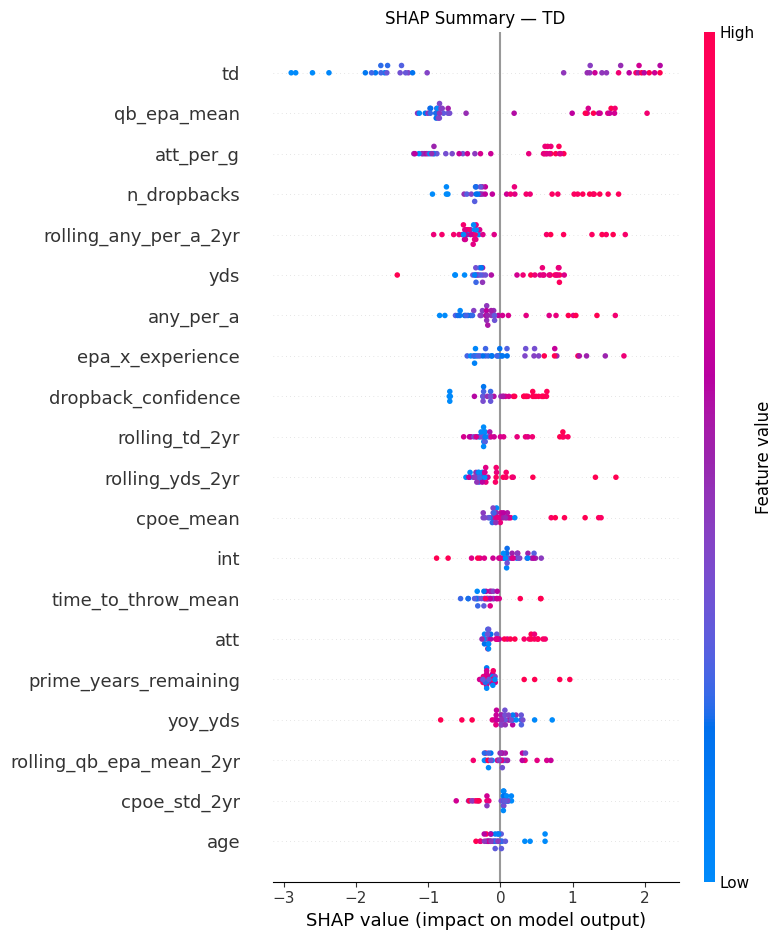

2026-06-29 20:56:30,721 - INFO - Generating SHAP summary plot for target: target_int


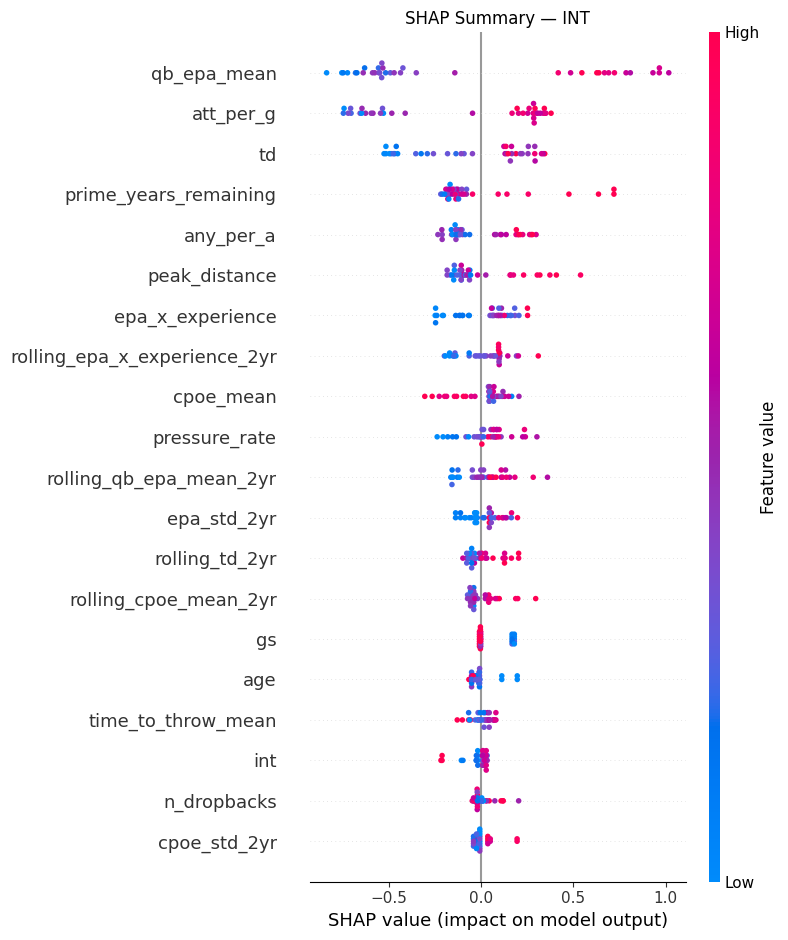

2026-06-29 20:56:31,212 - INFO - Generating SHAP summary plot for target: target_att


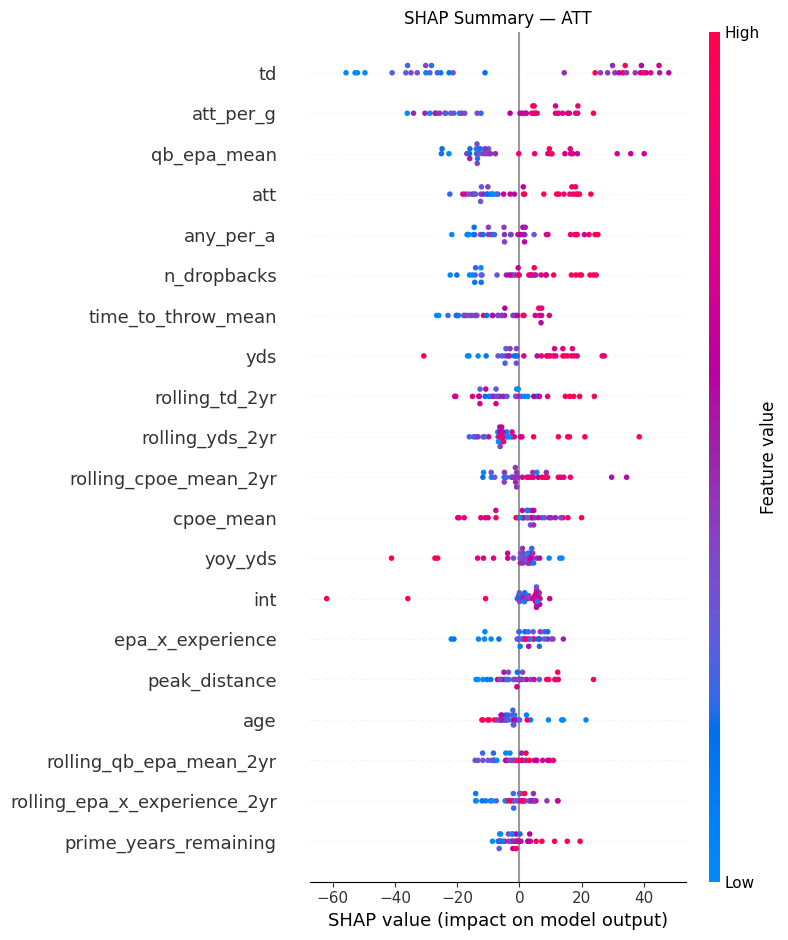

2026-06-29 20:56:31,942 - INFO - Generating SHAP summary plot for target: target_cmp


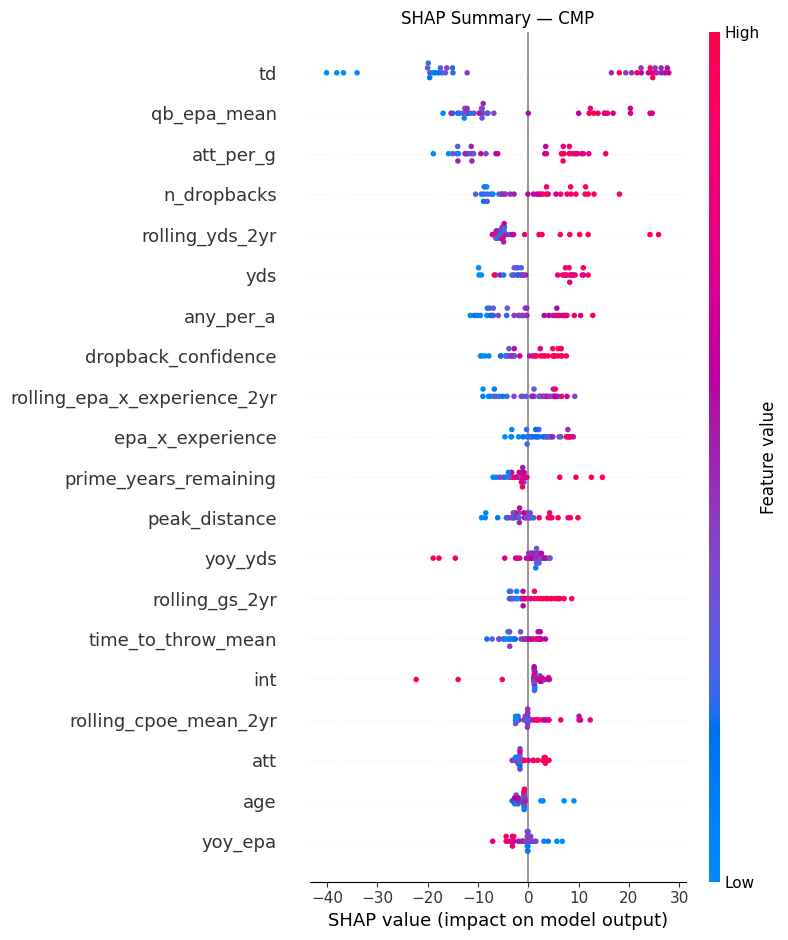

2026-06-29 20:56:32,513 - INFO - Generating SHAP summary plot for target: target_g


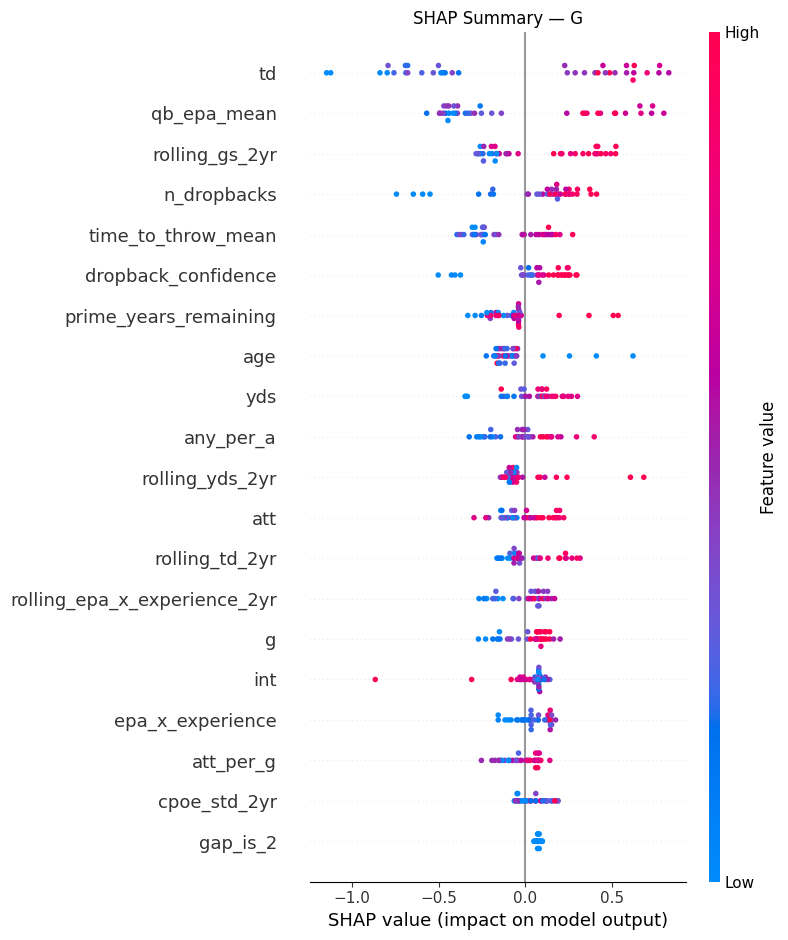

In [9]:
# ─── 8. SHAP Analysis ───────────────────────────────────────────────
"""
Generate SHAP summary plots for each target
"""

# Plot SHAP summary for each target
for target in target_cols:
    logger.info(f"Generating SHAP summary plot for target: {target}")
    model.plot_shap_summary(df_test_xgboost, target_col=target)

2026-06-29 20:56:33,074 - INFO - Generating SHAP waterfall plot for Patrick Mahomes (2024)
2026-06-29 20:56:33,075 - INFO -   Target: target_yds


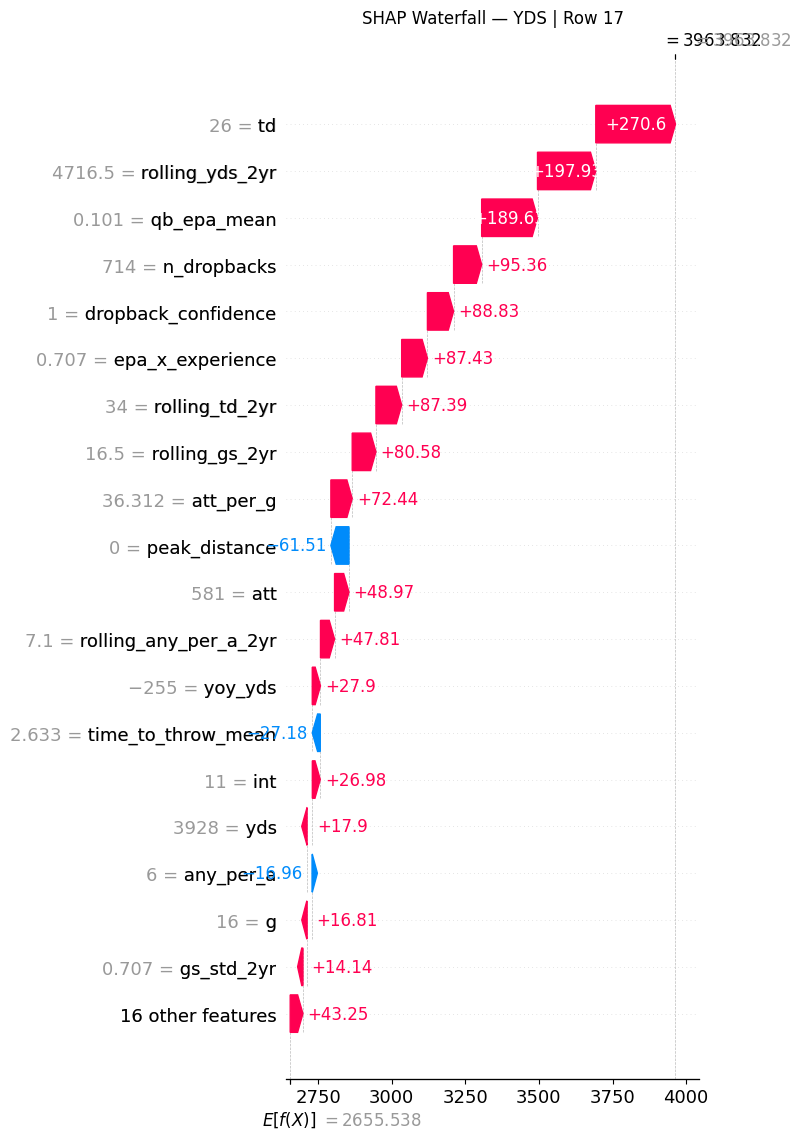

2026-06-29 20:56:33,896 - INFO -   Target: target_td


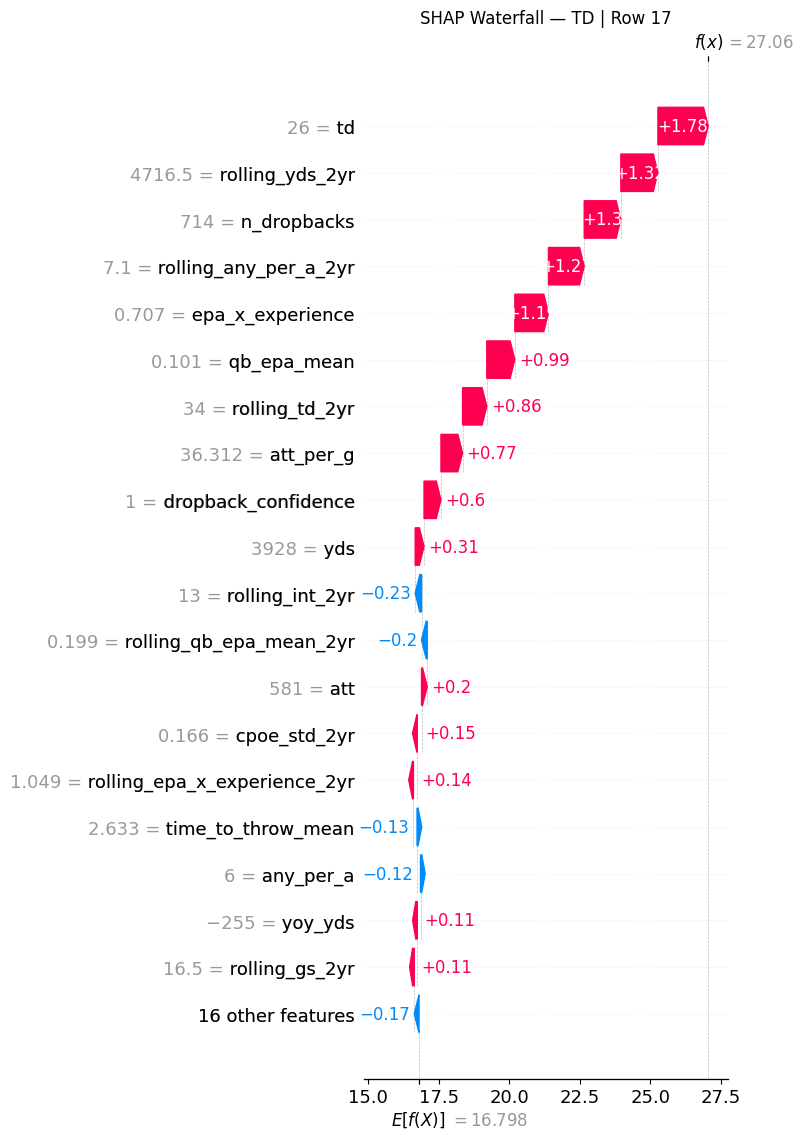

2026-06-29 20:56:34,412 - INFO -   Target: target_int


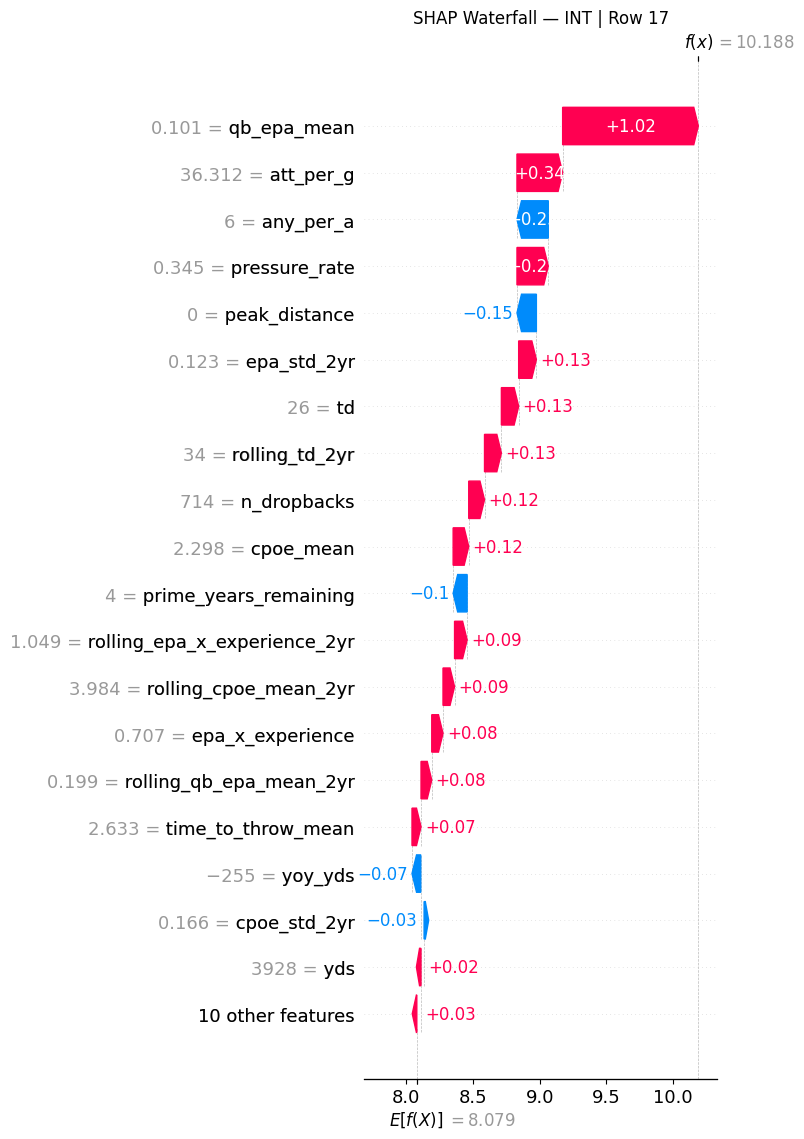

2026-06-29 20:56:35,274 - INFO -   Target: target_att


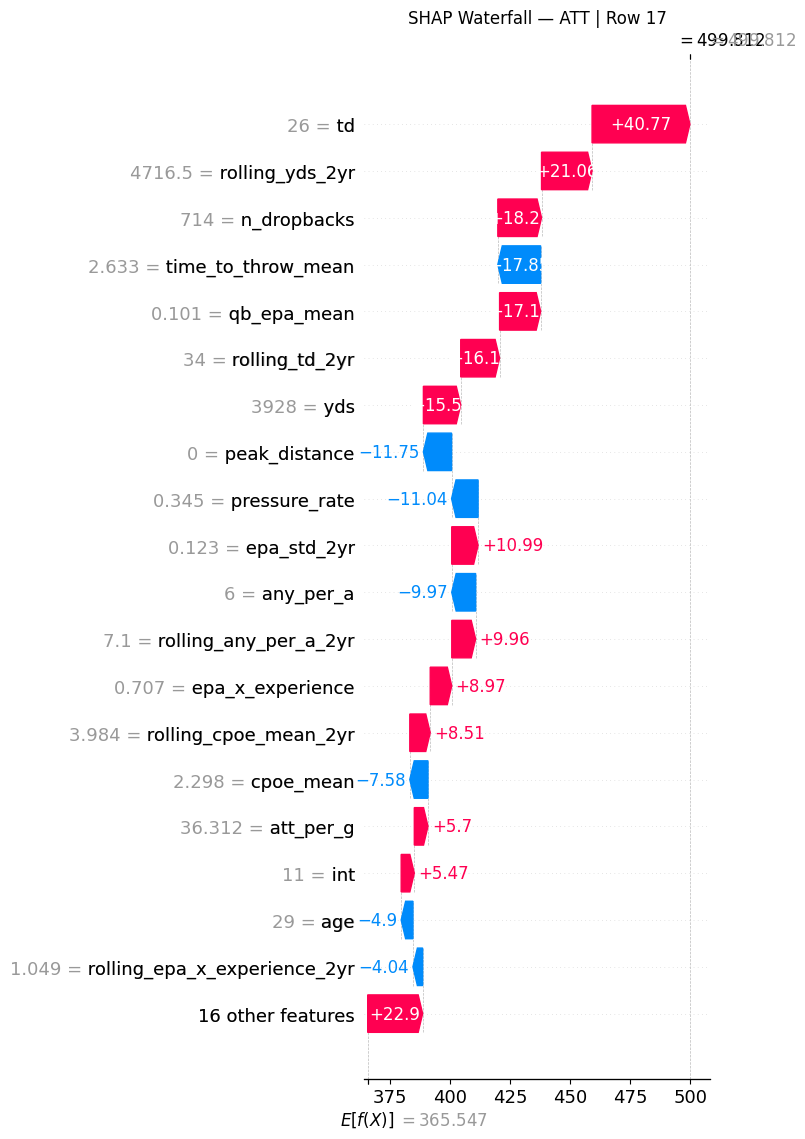

2026-06-29 20:56:35,898 - INFO -   Target: target_cmp


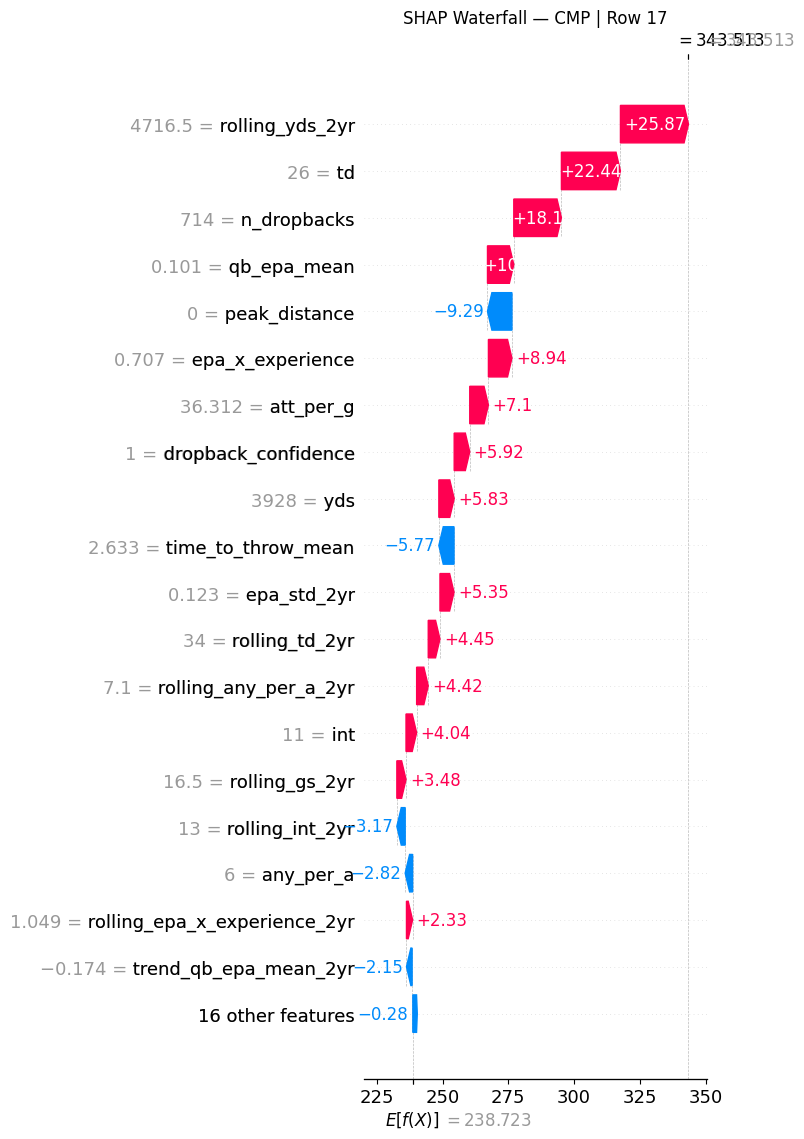

2026-06-29 20:56:36,521 - INFO -   Target: target_g


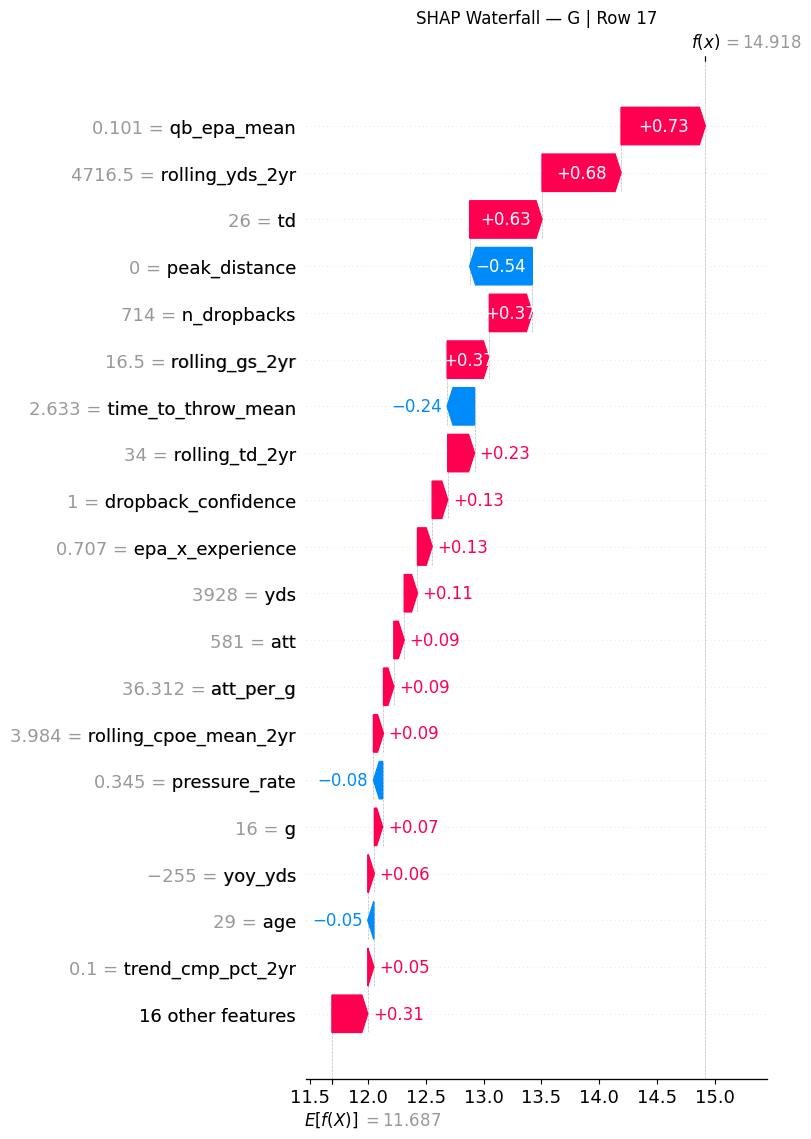

2026-06-29 20:56:37,030 - INFO - Generating SHAP waterfall plot for Lamar Jackson (2024)
2026-06-29 20:56:37,031 - INFO -   Target: target_yds


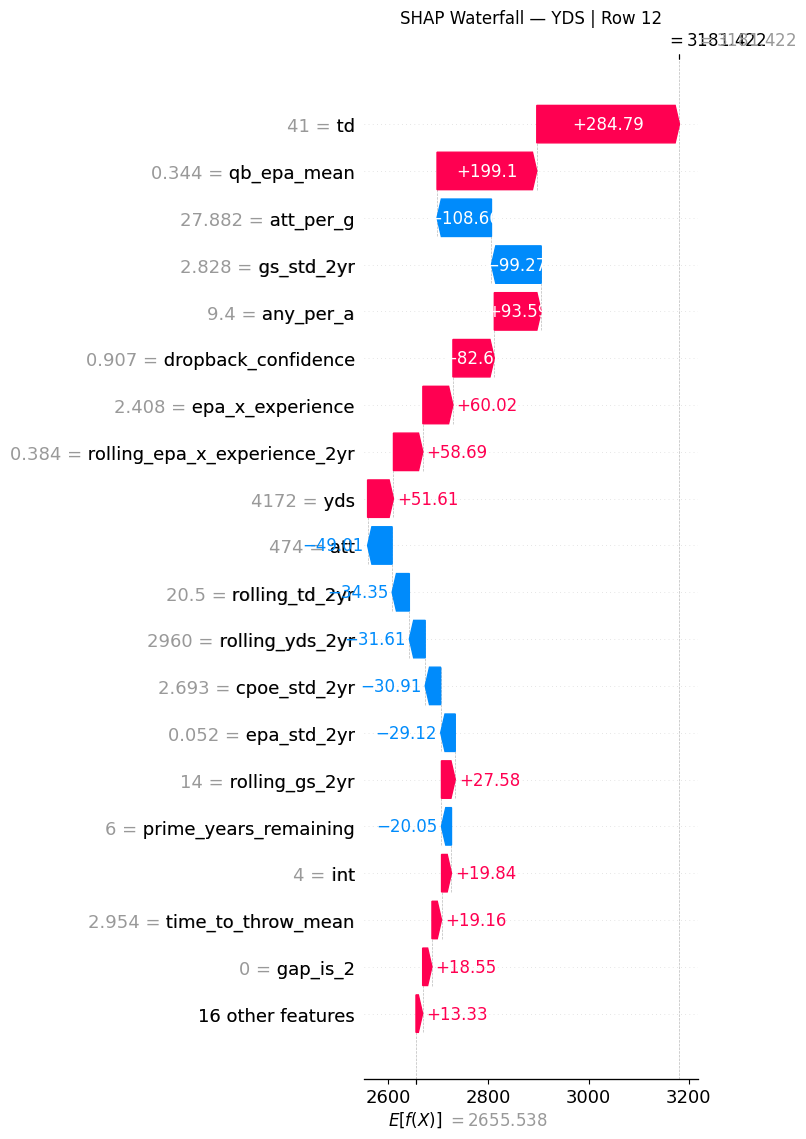

2026-06-29 20:56:37,536 - INFO -   Target: target_td


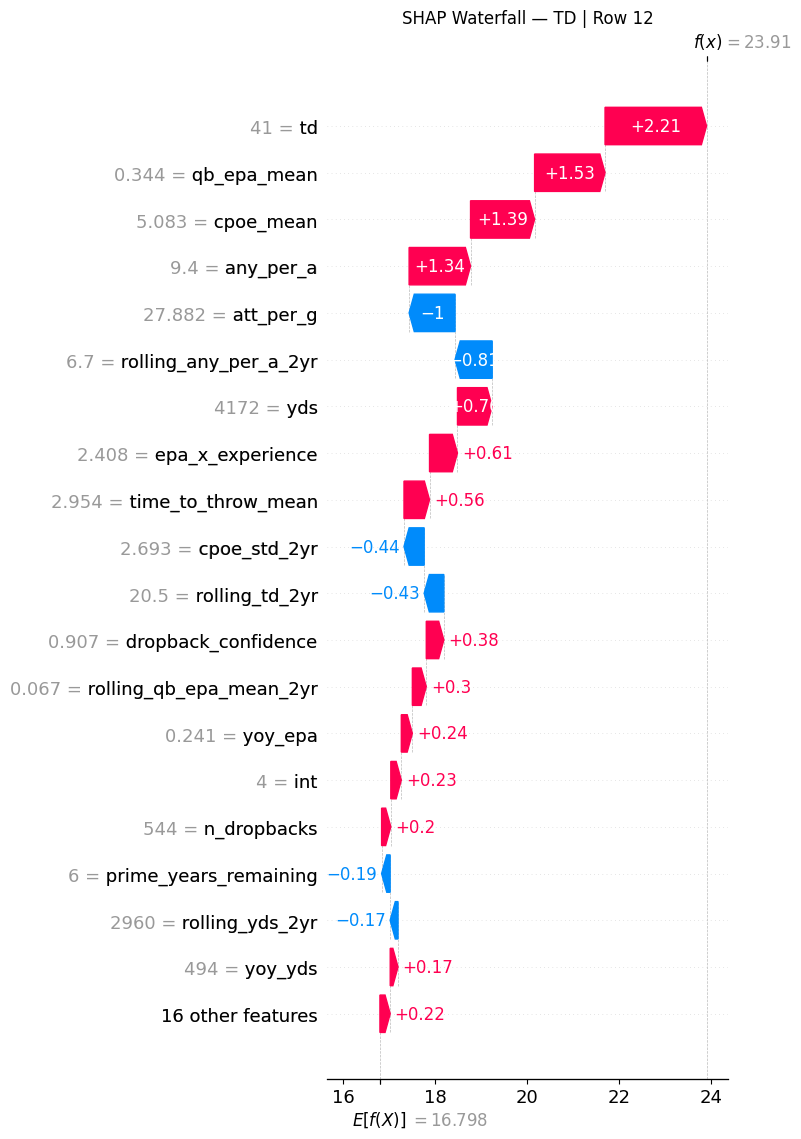

2026-06-29 20:56:38,311 - INFO -   Target: target_int


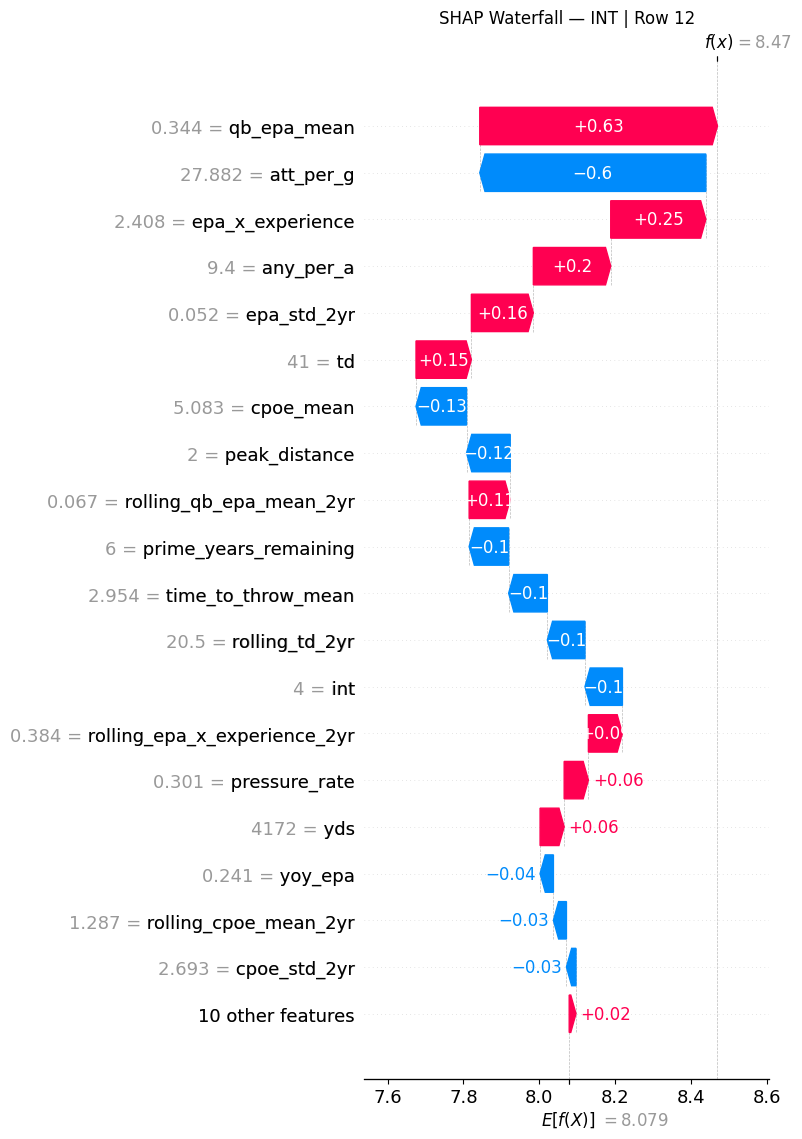

2026-06-29 20:56:38,857 - INFO -   Target: target_att


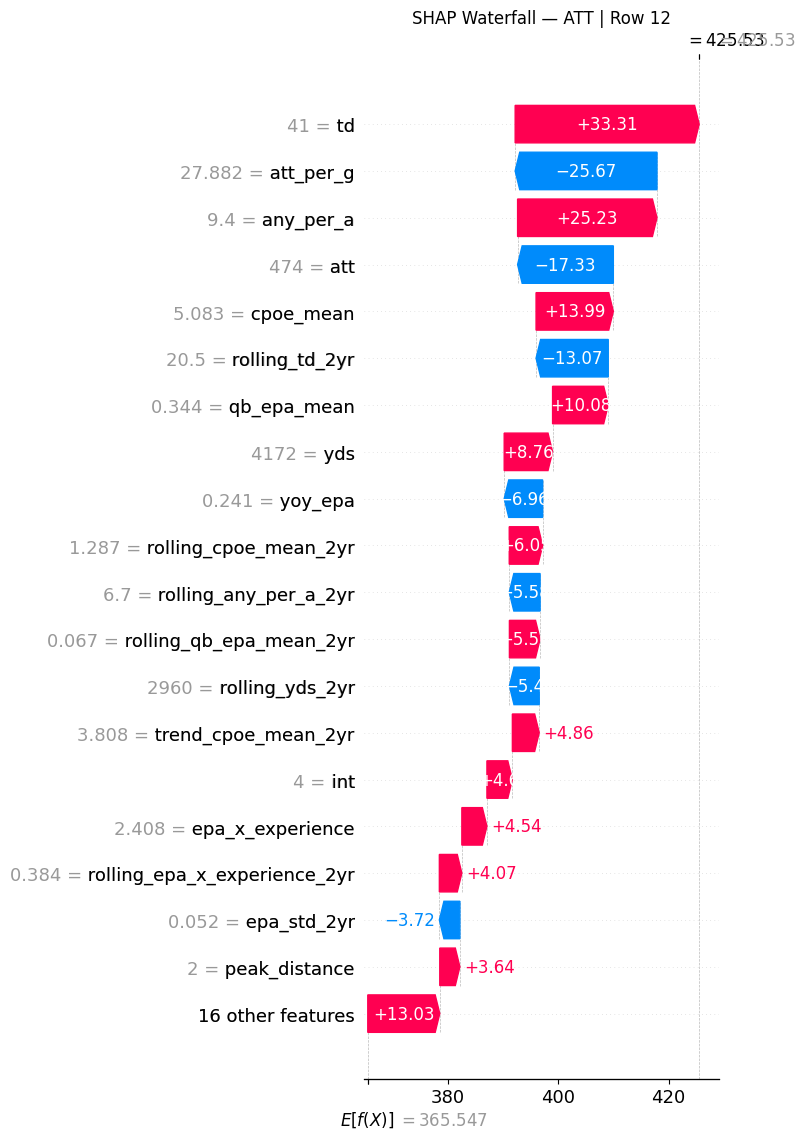

2026-06-29 20:56:39,506 - INFO -   Target: target_cmp


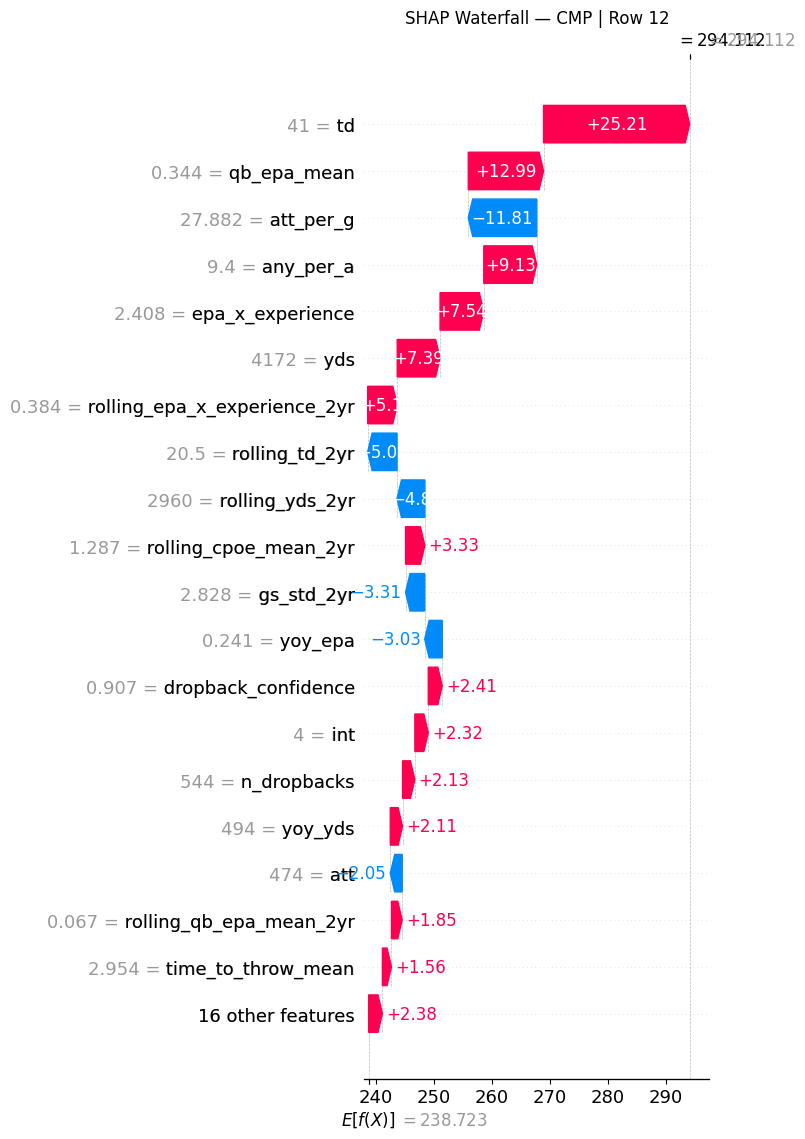

2026-06-29 20:56:40,190 - INFO -   Target: target_g


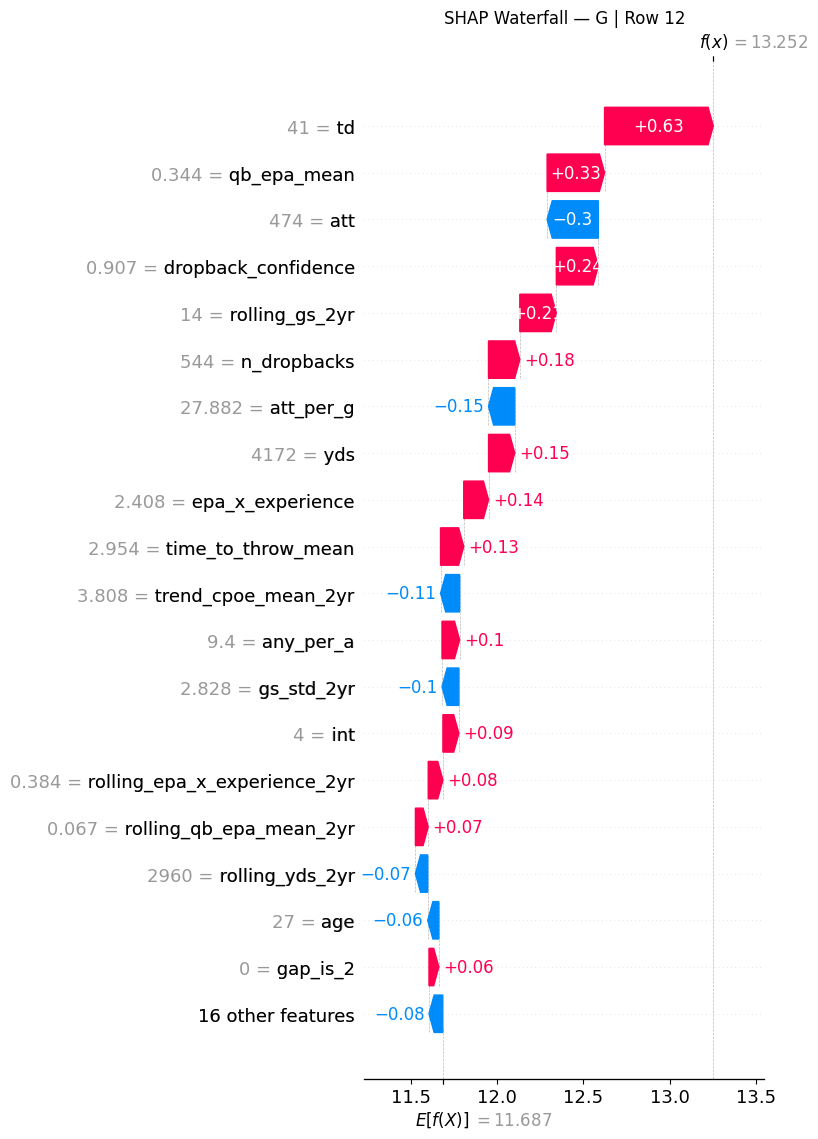

2026-06-29 20:56:40,812 - INFO - Generating SHAP waterfall plot for Jayden Daniels (2024)
2026-06-29 20:56:40,813 - INFO -   Target: target_yds


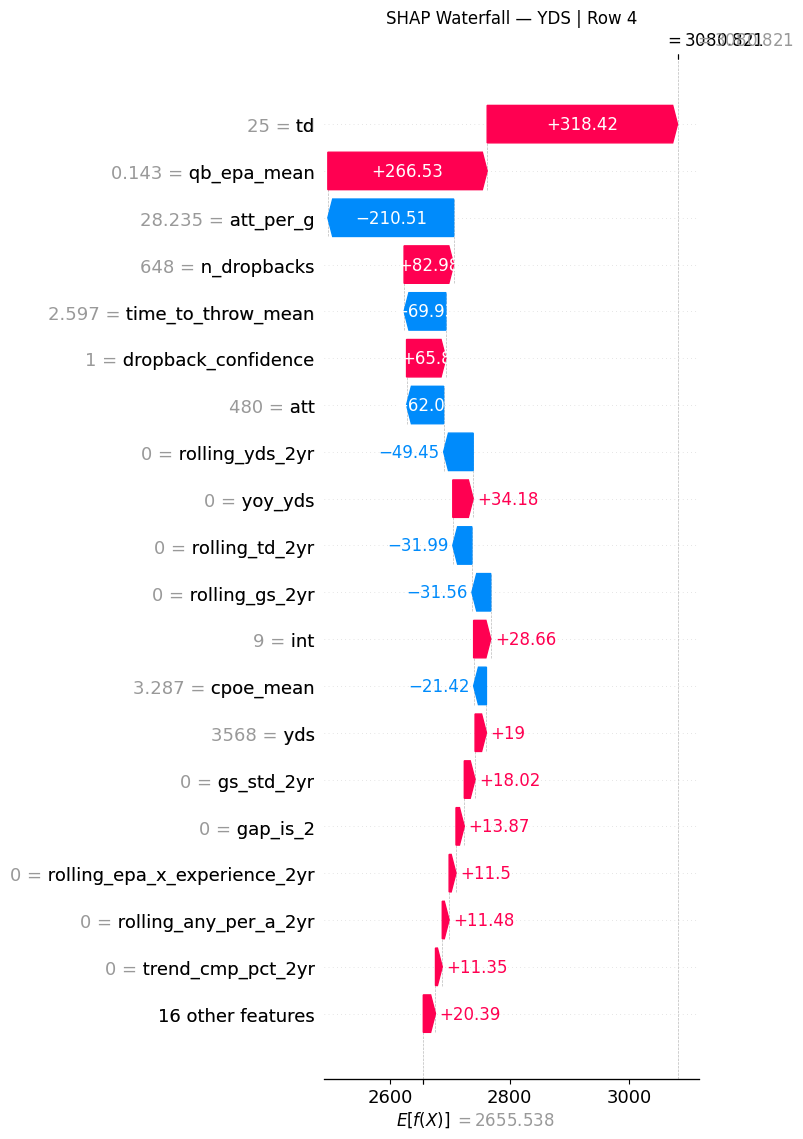

2026-06-29 20:56:41,345 - INFO -   Target: target_td


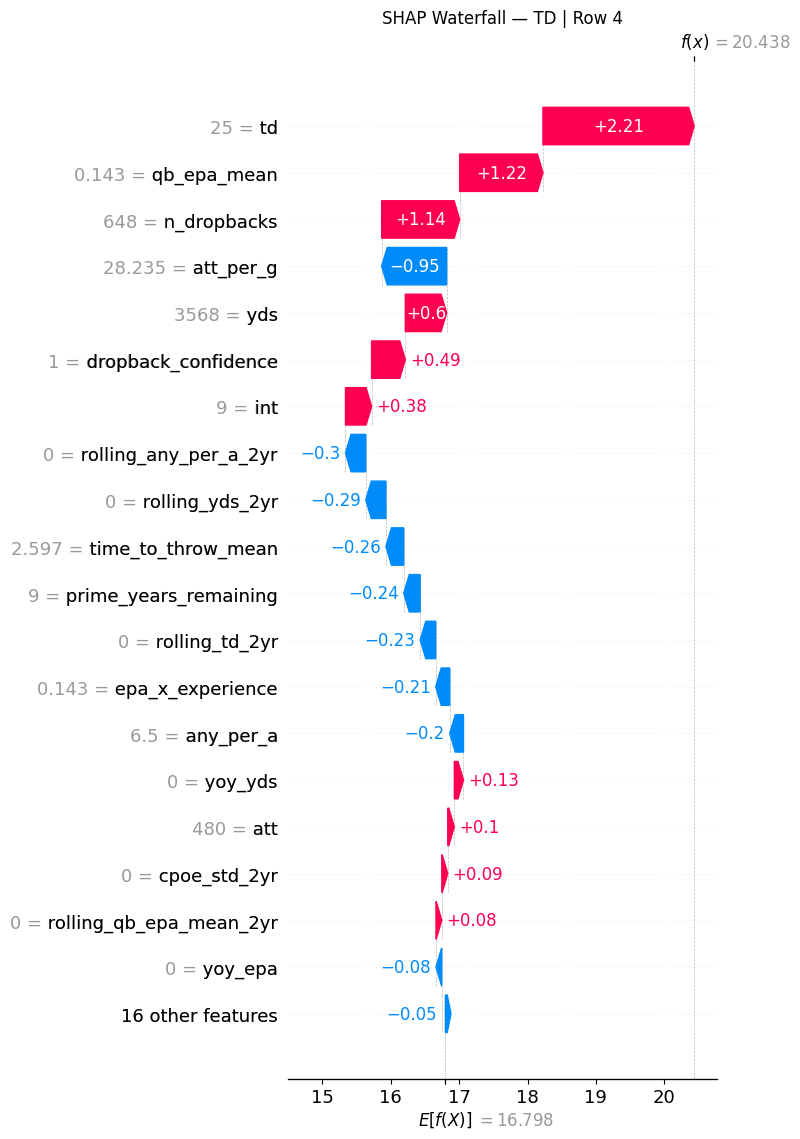

2026-06-29 20:56:42,205 - INFO -   Target: target_int


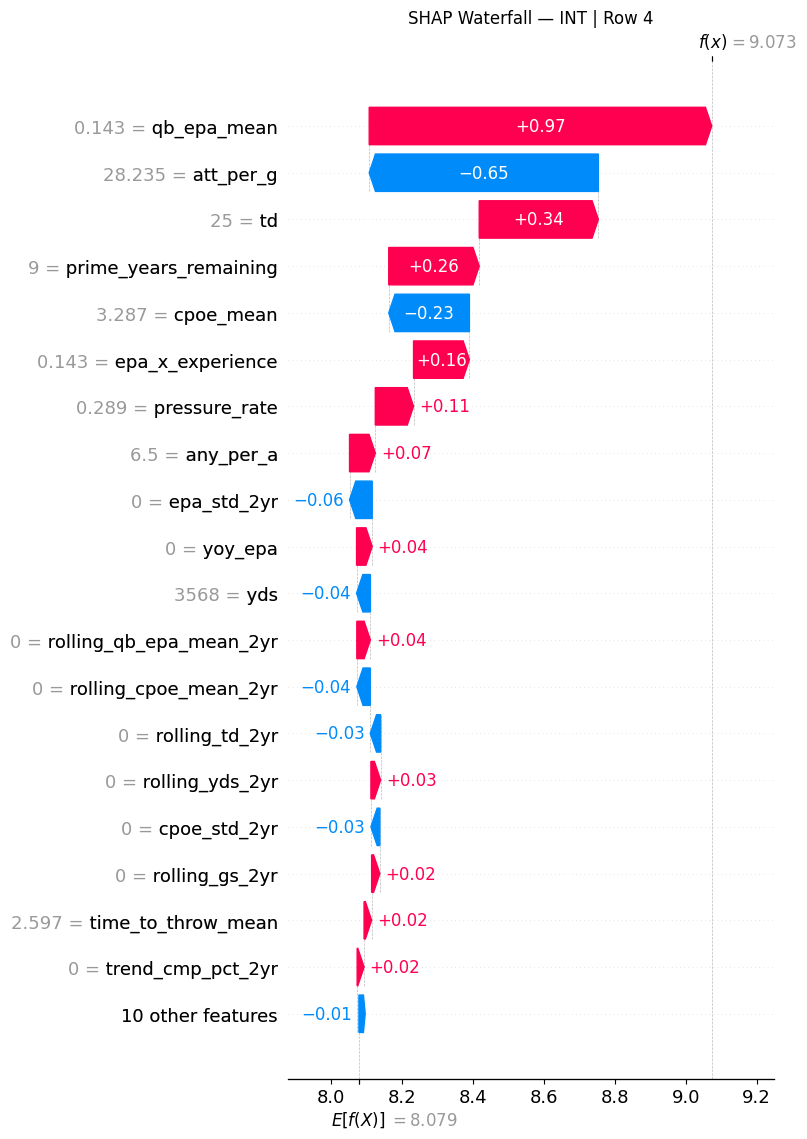

2026-06-29 20:56:42,761 - INFO -   Target: target_att


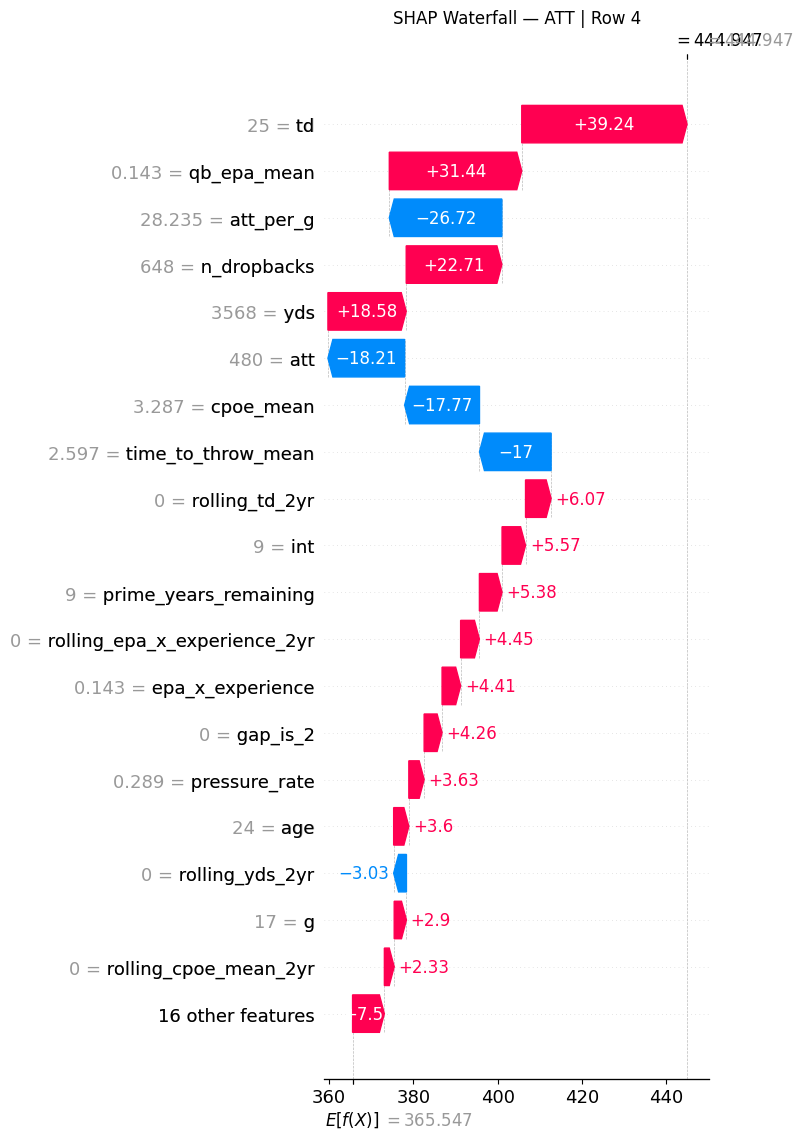

2026-06-29 20:56:43,327 - INFO -   Target: target_cmp


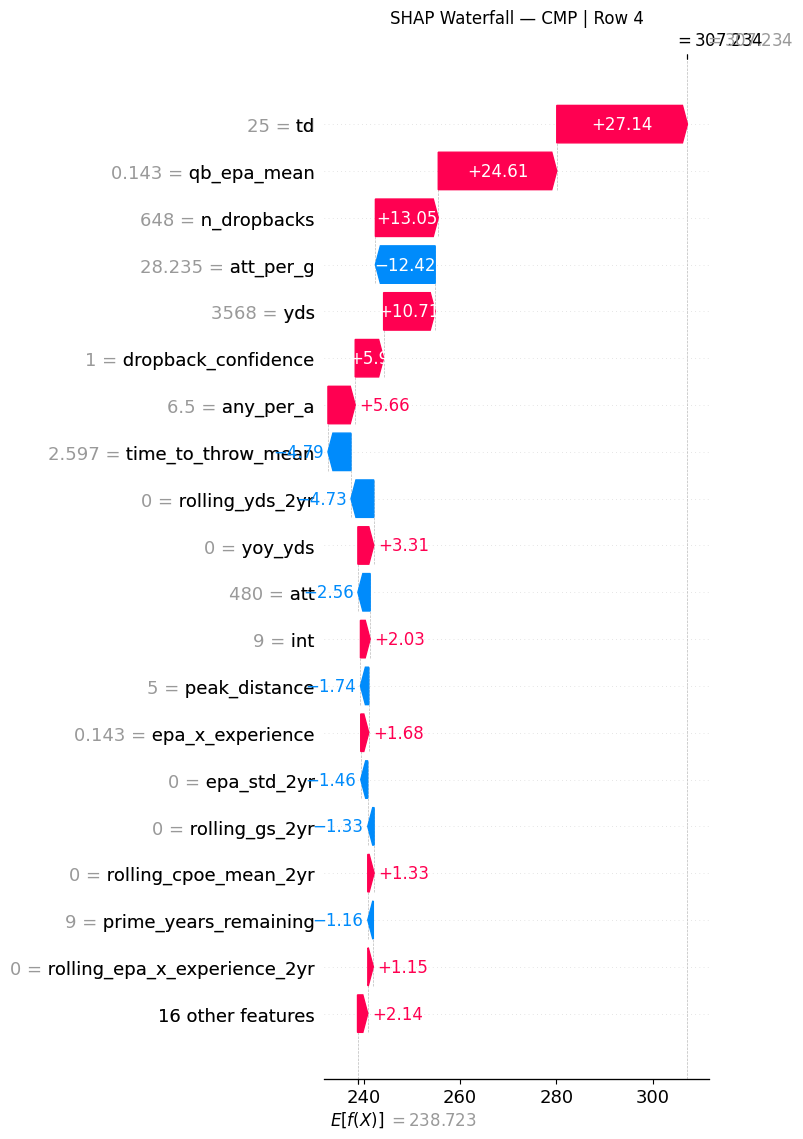

2026-06-29 20:56:43,872 - INFO -   Target: target_g


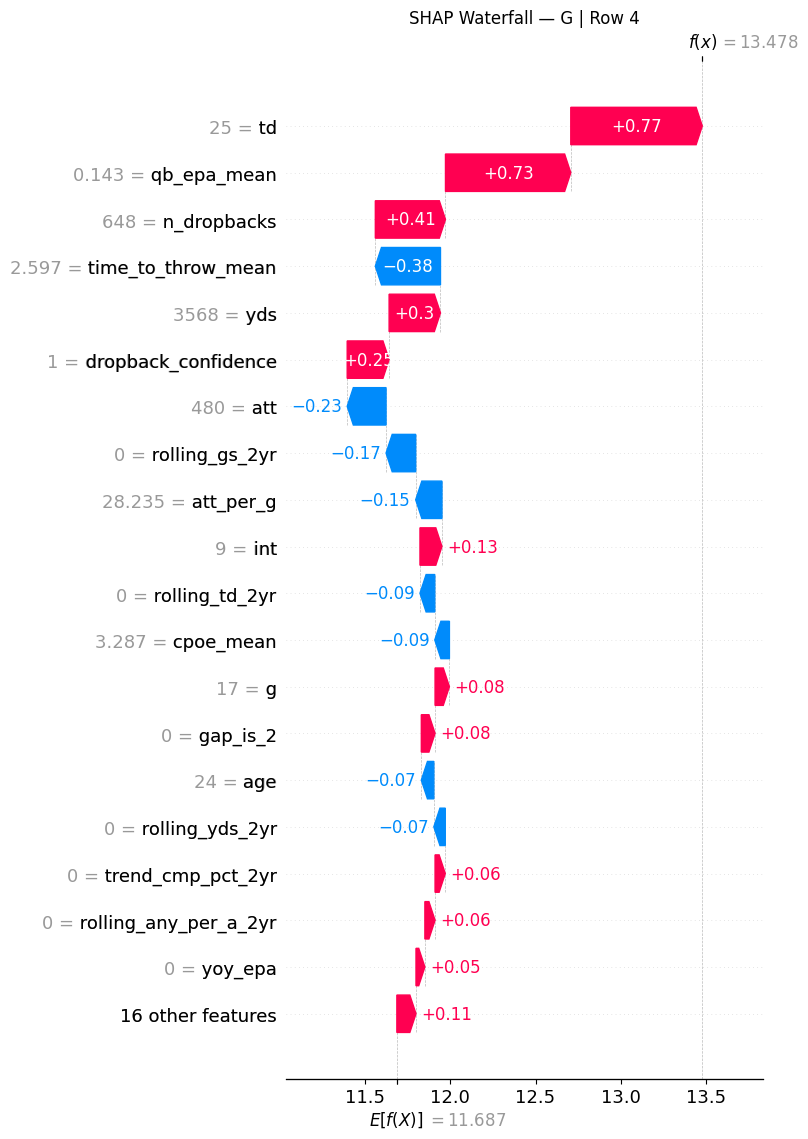

2026-06-29 20:56:44,416 - INFO - Generating SHAP waterfall plot for Joe Burrow (2024)
2026-06-29 20:56:44,417 - INFO -   Target: target_yds


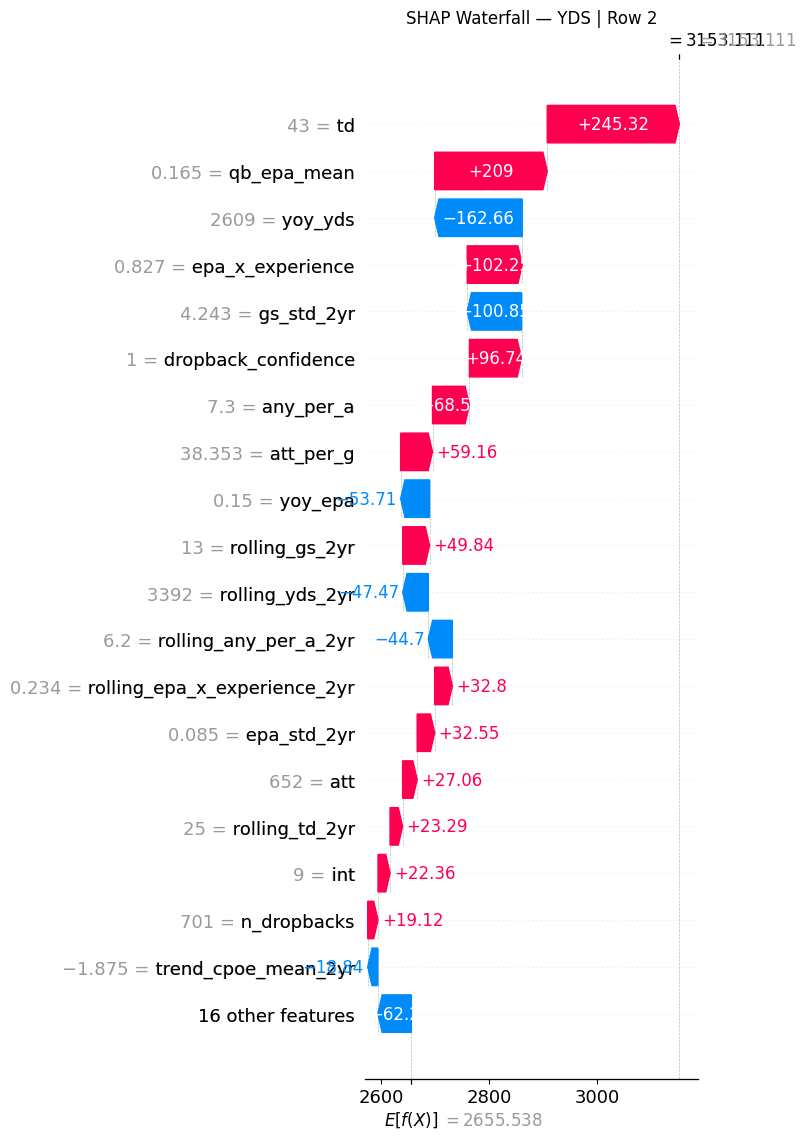

2026-06-29 20:56:45,291 - INFO -   Target: target_td


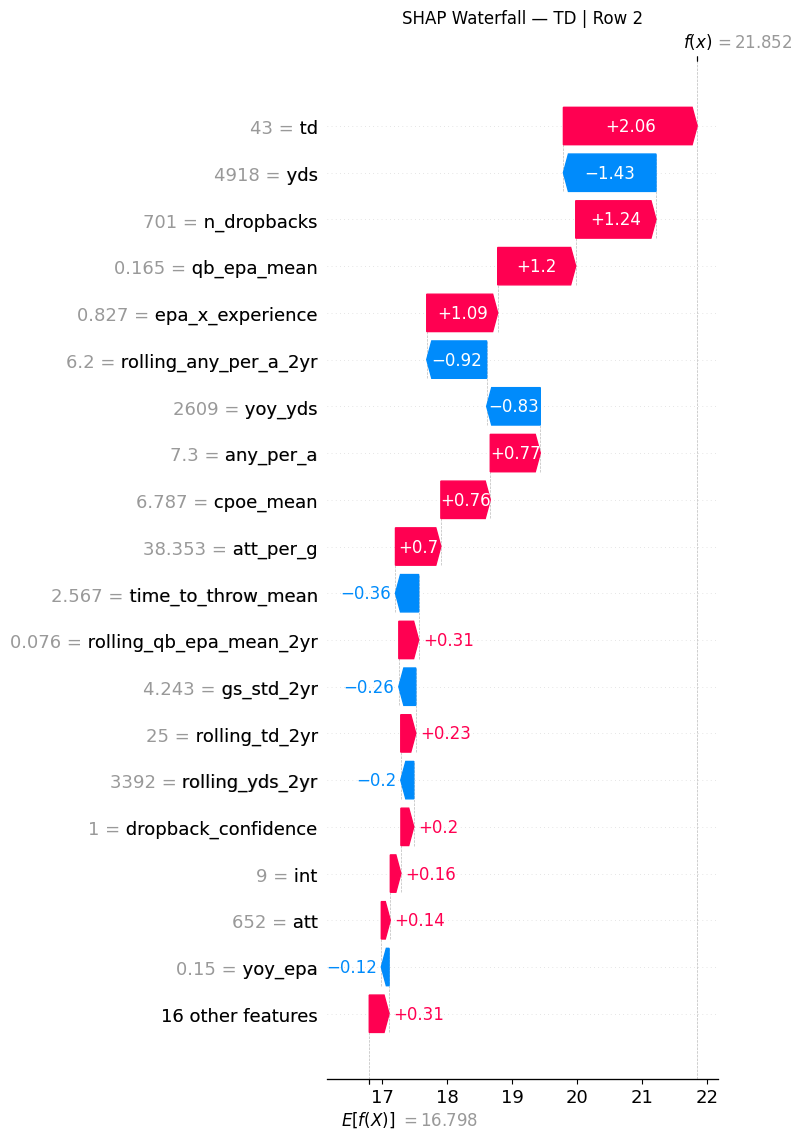

2026-06-29 20:56:45,972 - INFO -   Target: target_int


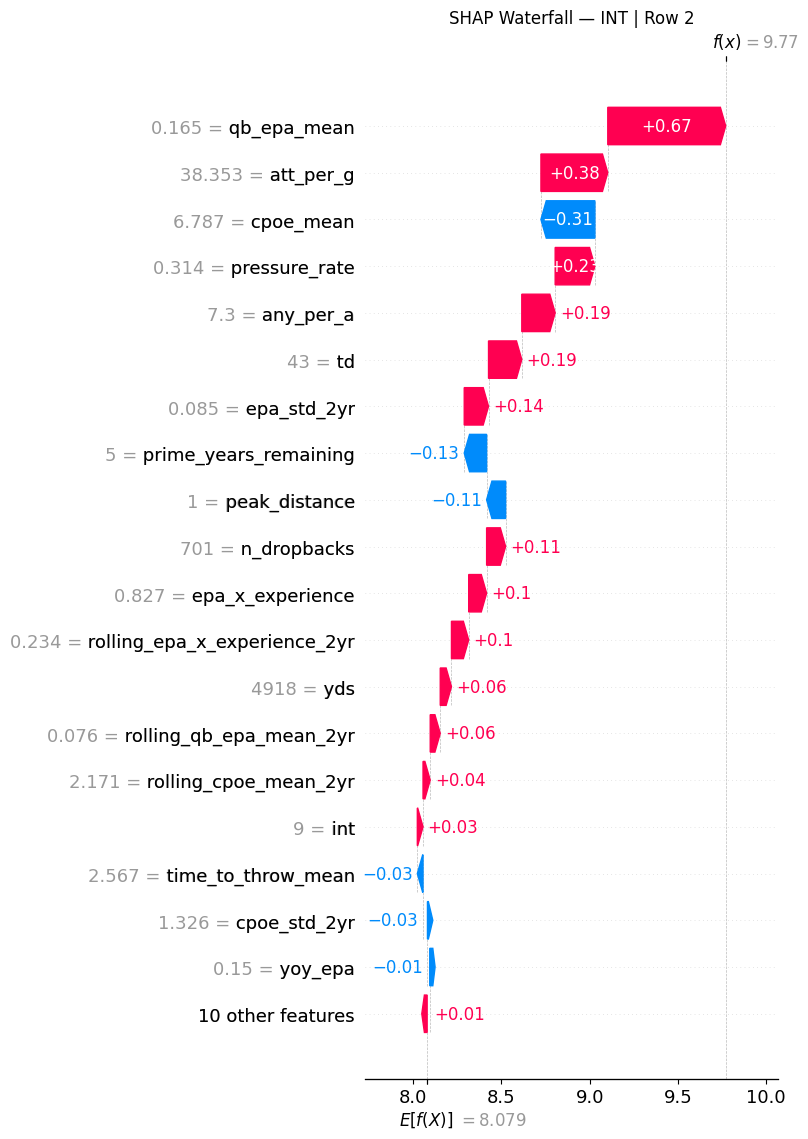

2026-06-29 20:56:46,529 - INFO -   Target: target_att


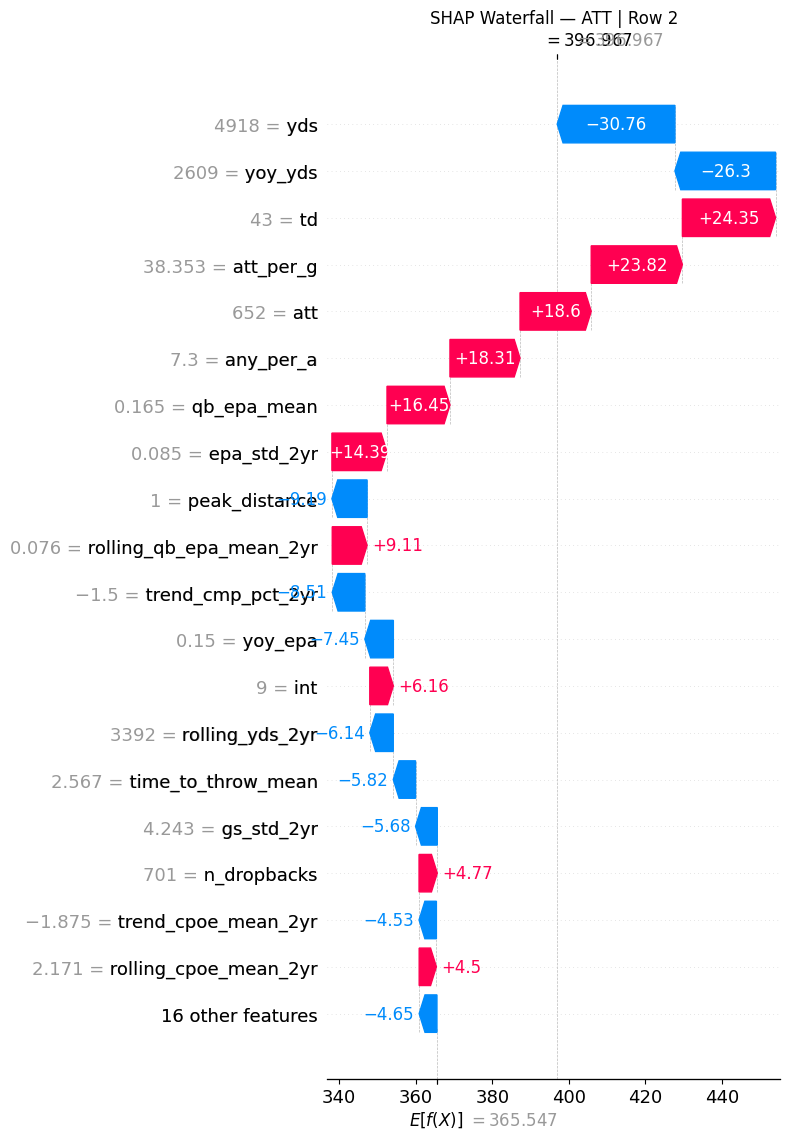

2026-06-29 20:56:47,058 - INFO -   Target: target_cmp


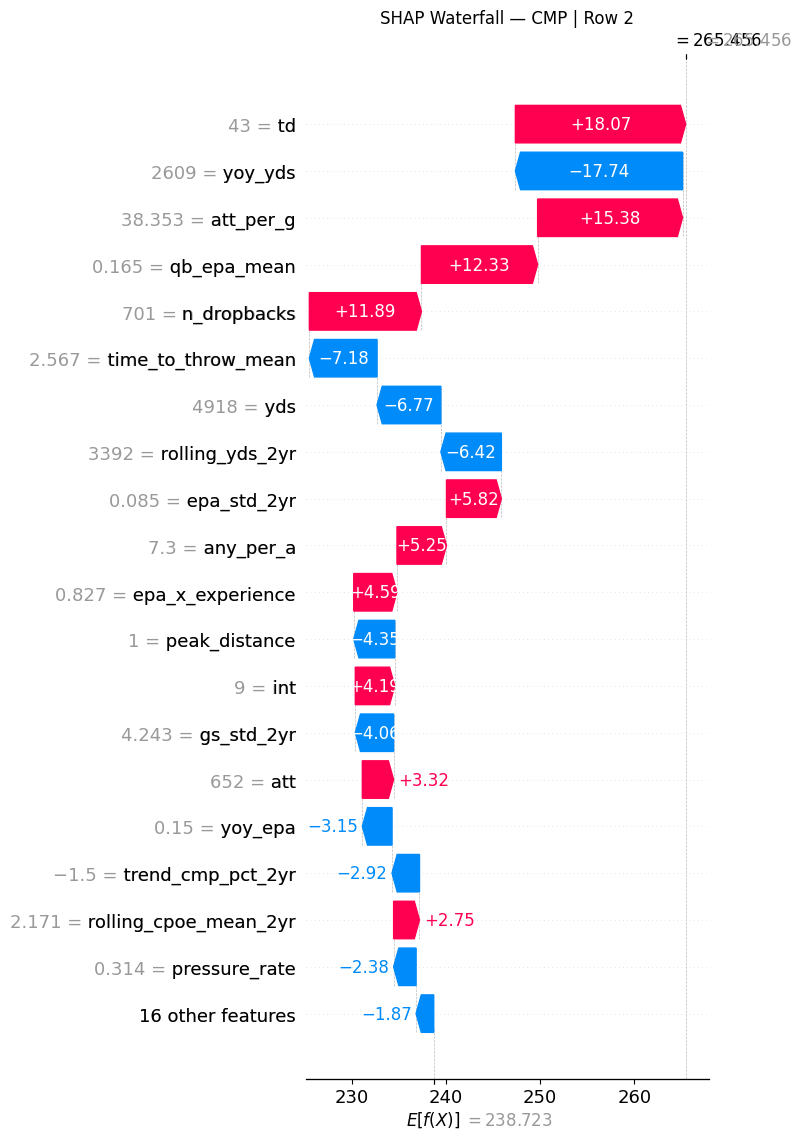

2026-06-29 20:56:47,615 - INFO -   Target: target_g


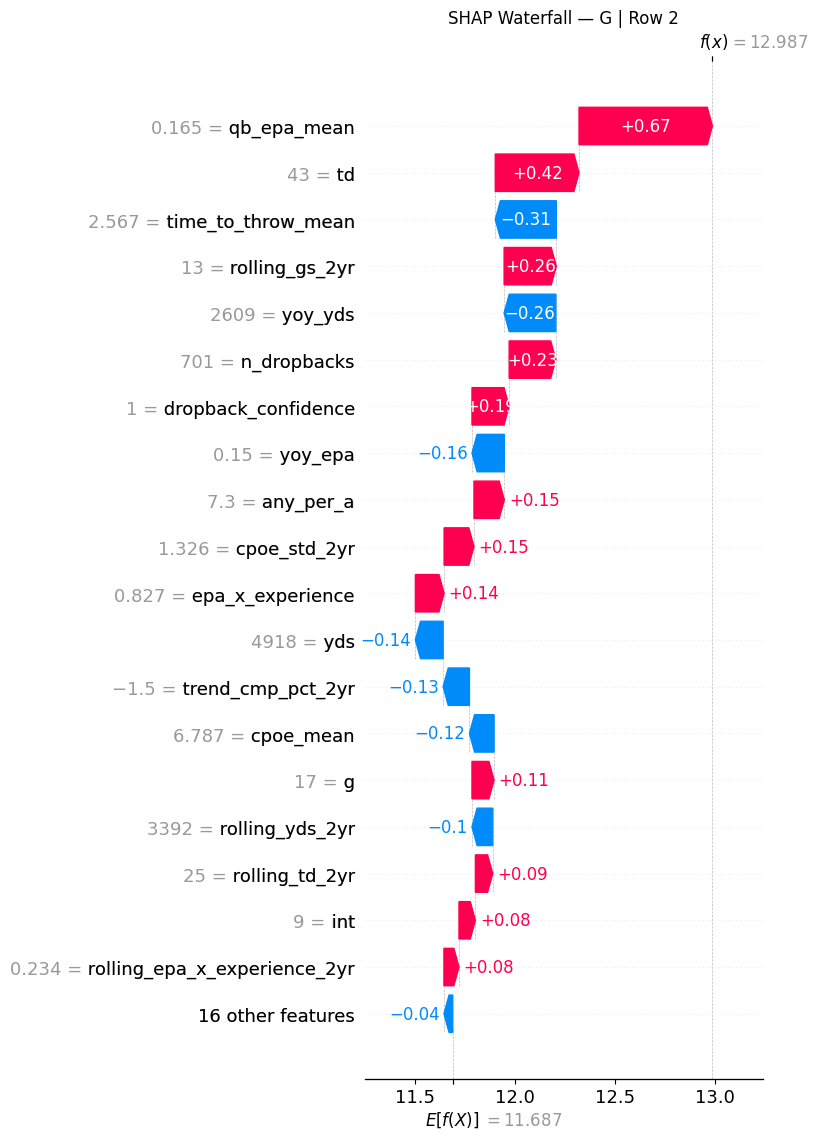

In [10]:
# ─── 9. Individual Player SHAP Waterfall ────────────────────────────
"""
Generate SHAP waterfall plots for selected players to illustrate individual predictions
"""

# Plot SHAP waterfall for selected players
players_to_plot = [
    {"player": "Patrick Mahomes", "season": 2024}, # Expected to have a strong positive prediction
    {"player": "Lamar Jackson", "season": 2024}, # Mobile QB with unique skill set
    {"player": "Jayden Daniels", "season": 2024}, # Sophomore slump case
    {"player": "Joe Burrow", "season": 2024} # Injury case
]

# Map player to row index in test set
player_indices = {player["player"]: i for i, player in enumerate(df_test_xgboost.to_dict('records'))}

for player in players_to_plot:
    player_name = player["player"]
    season = player["season"]
    logger.info(f"Generating SHAP waterfall plot for {player_name} ({season})")

    if player_name in player_indices:
        for target in target_cols:
            logger.info(f"  Target: {target}")
            idx = player_indices[player_name]
            model.plot_shap_waterfall(df_test_xgboost, target, idx)
    else:
        logger.warning(f"Player {player_name} not found in test set.")

In [11]:
# ─── 10. Prediction Spot Check ──────────────────────────────────────
"""
Use prediction_summary() on test set.
Compare XGBoost vs Ridge side by side
"""

# Generate prediction summary for XGBoost predictions
df_prediction_summary_xgboost: pd.DataFrame = prediction_summary(
    df=df_test_xgboost,
    predictions = predictions_xgboost,
    target_cols=target_cols,
    player_col="player",
    season_col="season",
)

# Generate prediction summary for ridge predictions
df_prediction_summary_ridge: pd.DataFrame = prediction_summary(
    df=df_test_ridge,
    predictions=predictions_ridge,
    target_cols=target_cols,
    player_col="player",
    season_col="season",
)

# Display prediction summary for select players
for player in players_to_plot:
    player_name = player["player"]

    xgb_rows = df_prediction_summary_xgboost[
        df_prediction_summary_xgboost["player"] == player_name
    ][["target", "actual", "predicted"]].rename(columns={"predicted": "xgb_predicted"})

    ridge_rows = df_prediction_summary_ridge[
        df_prediction_summary_ridge["player"] == player_name
    ][["target", "predicted"]].rename(columns={"predicted": "ridge_predicted"})

    comparison = xgb_rows.merge(ridge_rows, on="target")
    comparison["xgb_error"]   = comparison["actual"] - comparison["xgb_predicted"]
    comparison["ridge_error"] = comparison["actual"] - comparison["ridge_predicted"]

    print(f"=== {player_name} ===")
    print(comparison.to_string(index=False))
    print()



=== Patrick Mahomes ===
    target  actual  xgb_predicted  ridge_predicted   xgb_error  ridge_error
target_att   502.0     499.811707       487.811768    2.188293    14.188232
target_cmp   315.0     343.512665       325.046025  -28.512665   -10.046025
  target_g    14.0      14.917639        14.552669   -0.917639    -0.552669
target_int    11.0      10.188255         9.753969    0.811745     1.246031
 target_td    22.0      27.060076        21.991130   -5.060076     0.008870
target_yds  3587.0    3963.831299      3533.565563 -376.831299    53.434437

=== Lamar Jackson ===
    target  actual  xgb_predicted  ridge_predicted   xgb_error  ridge_error
target_att   302.0     425.529877       538.303534 -123.529877  -236.303534
target_cmp   192.0     294.112091       363.585775 -102.112091  -171.585775
  target_g    13.0      13.251670        16.311018   -0.251670    -3.311018
target_int     7.0       8.469738        12.031924   -1.469738    -5.031924
 target_td    21.0      23.910423        

2026-06-29 20:56:48,552 - INFO - Conducting Residual Analysis


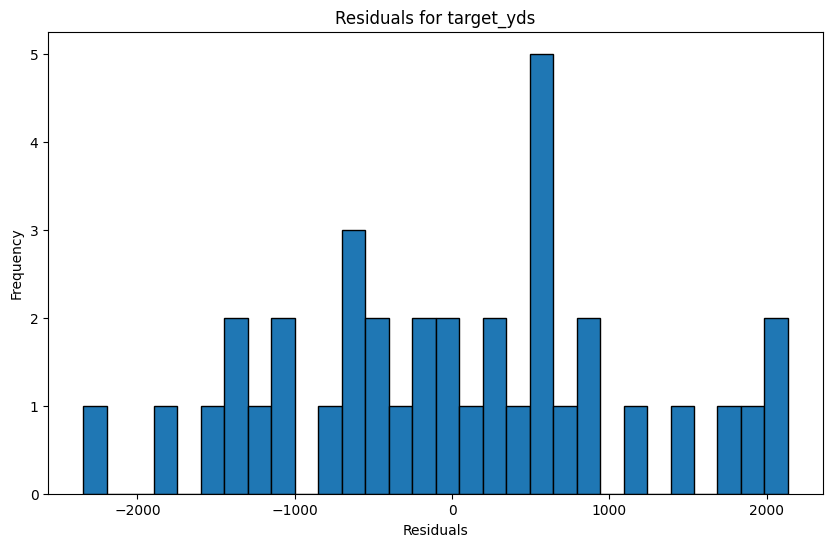

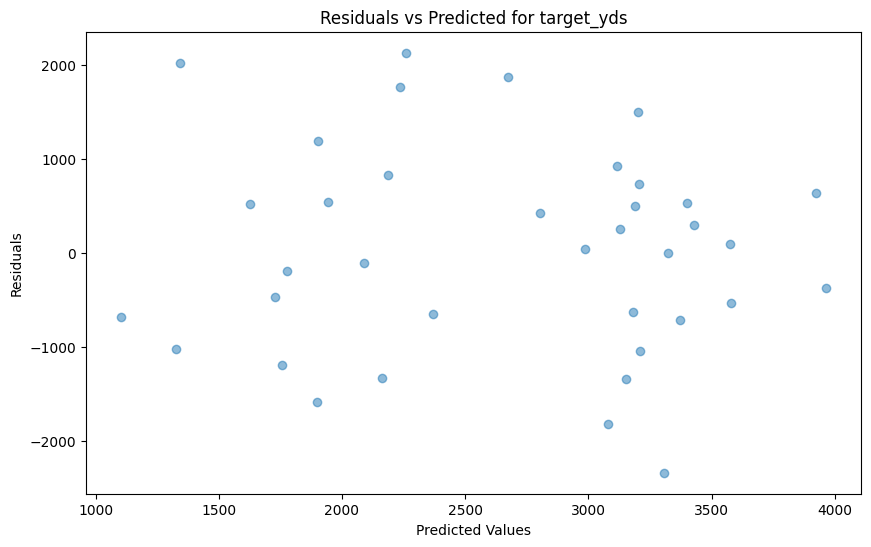

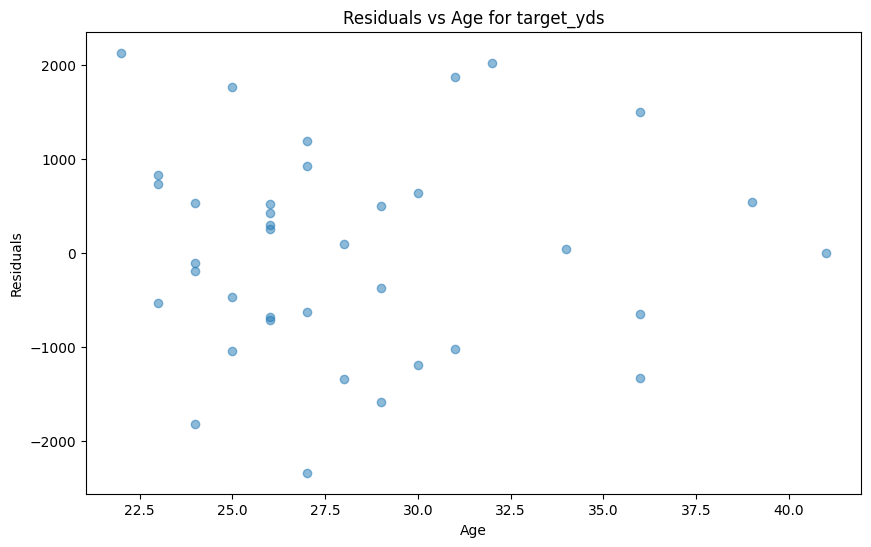

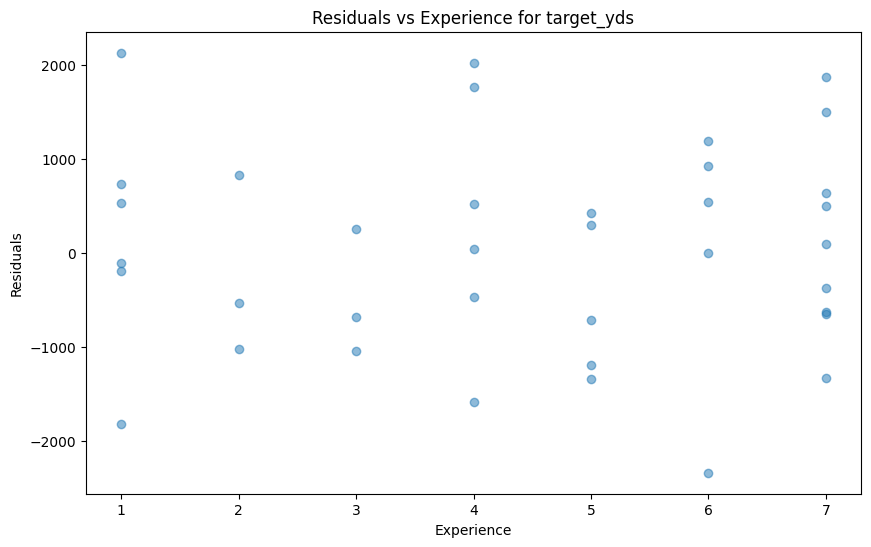

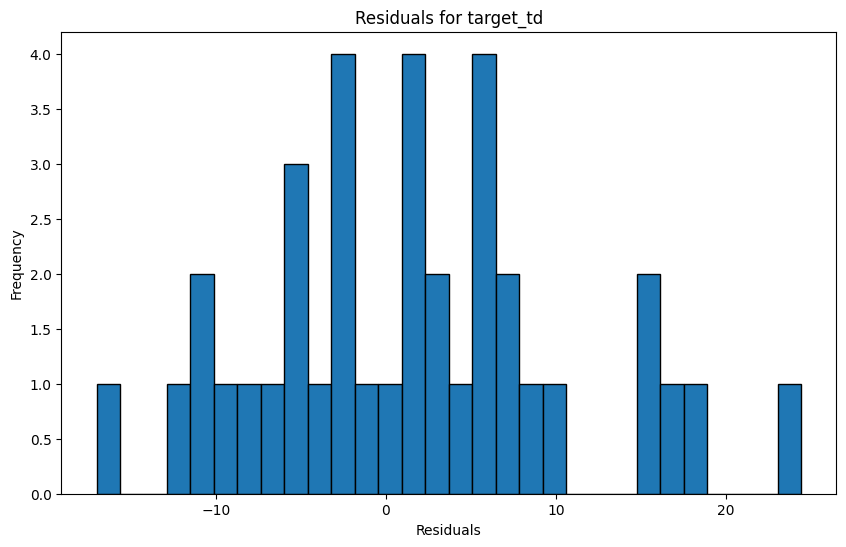

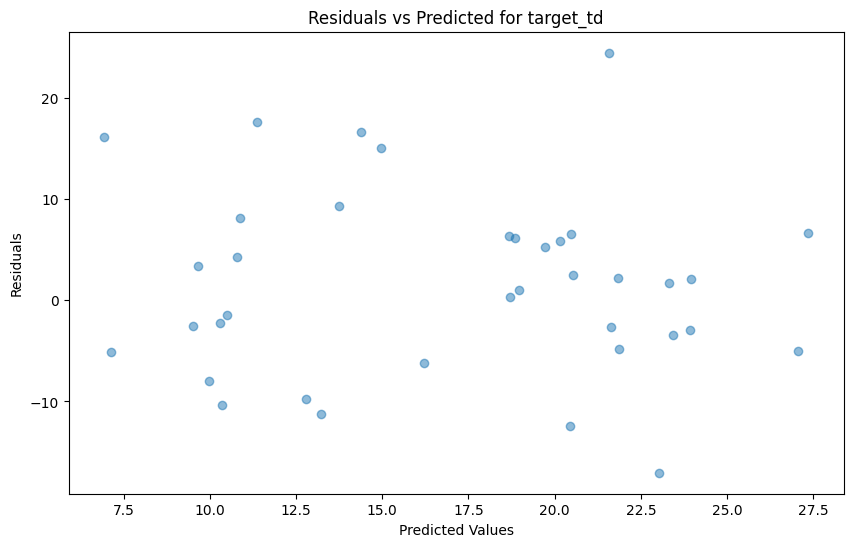

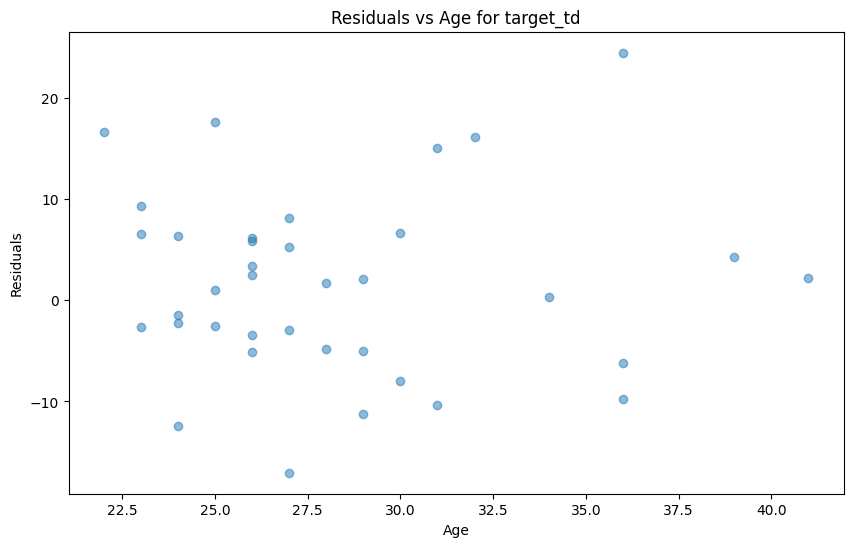

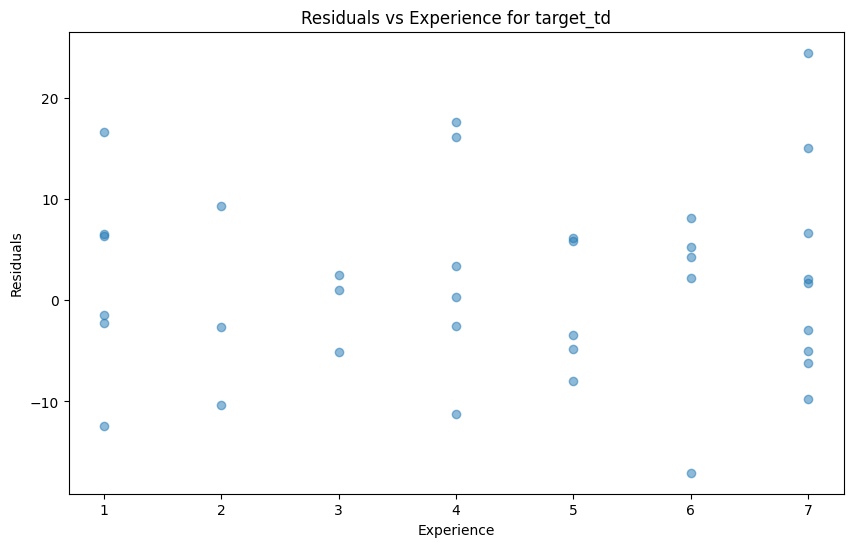

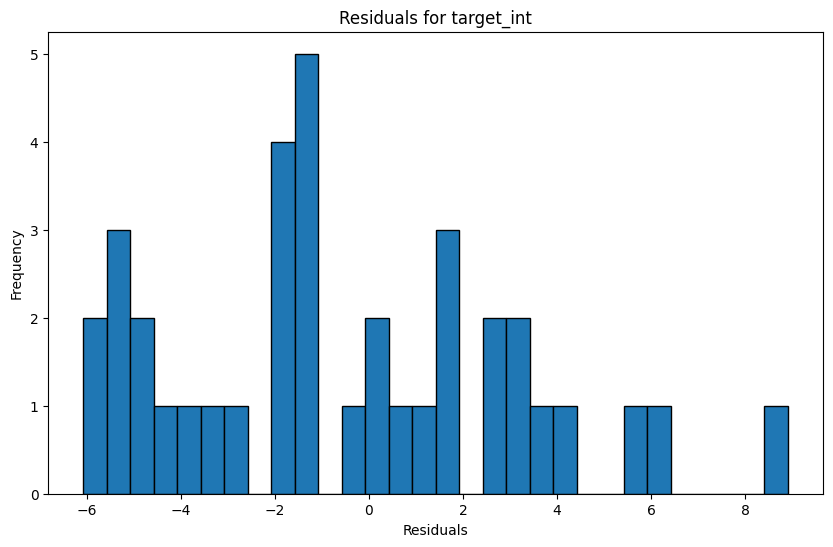

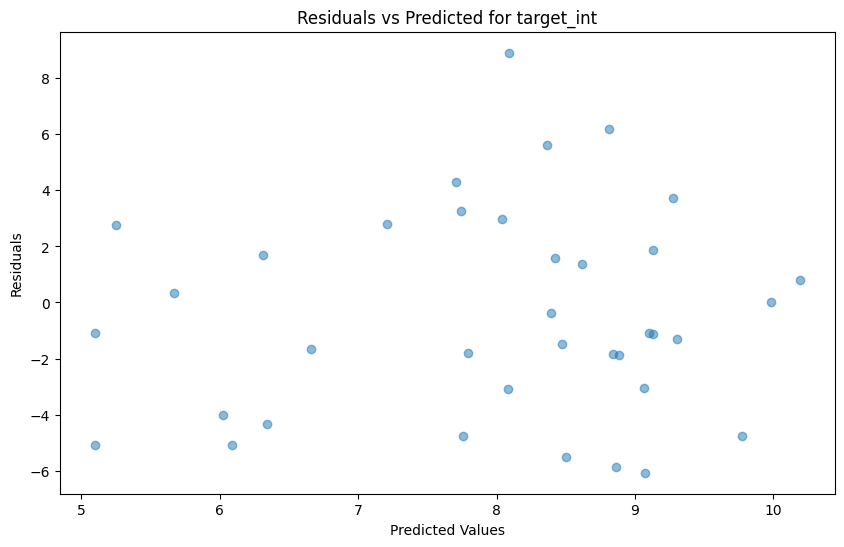

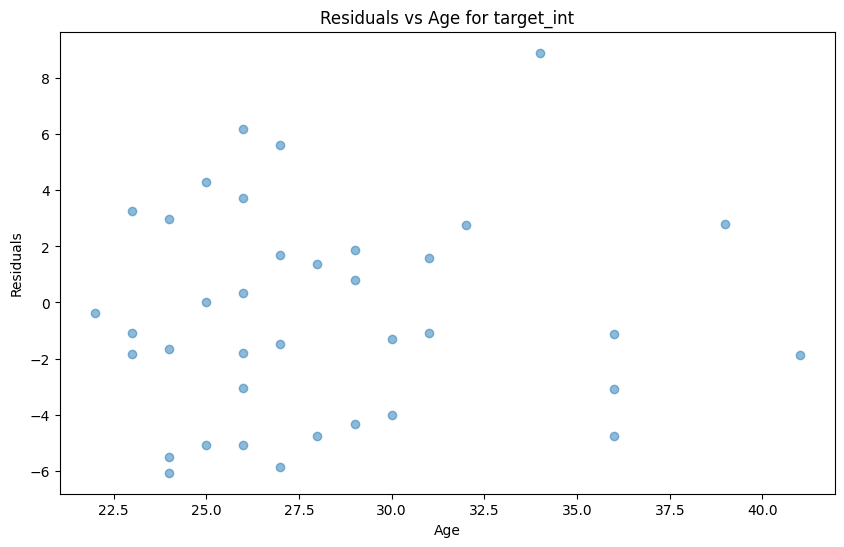

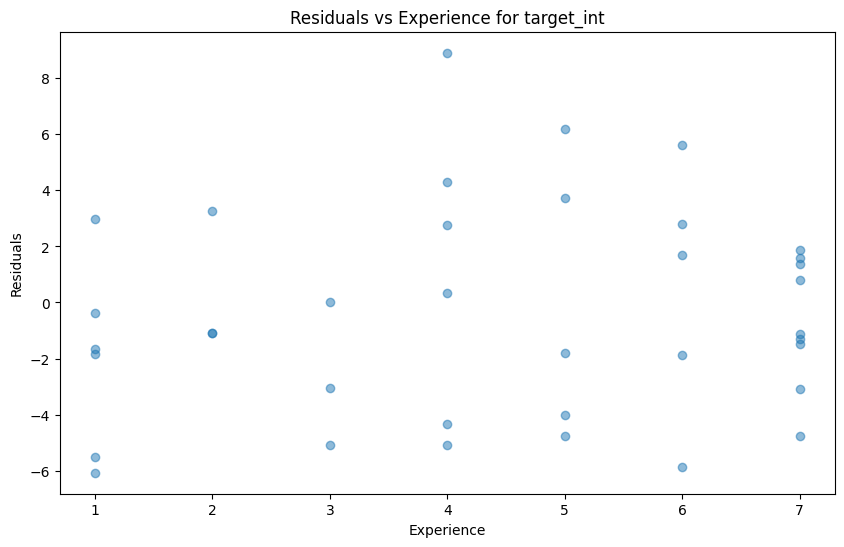

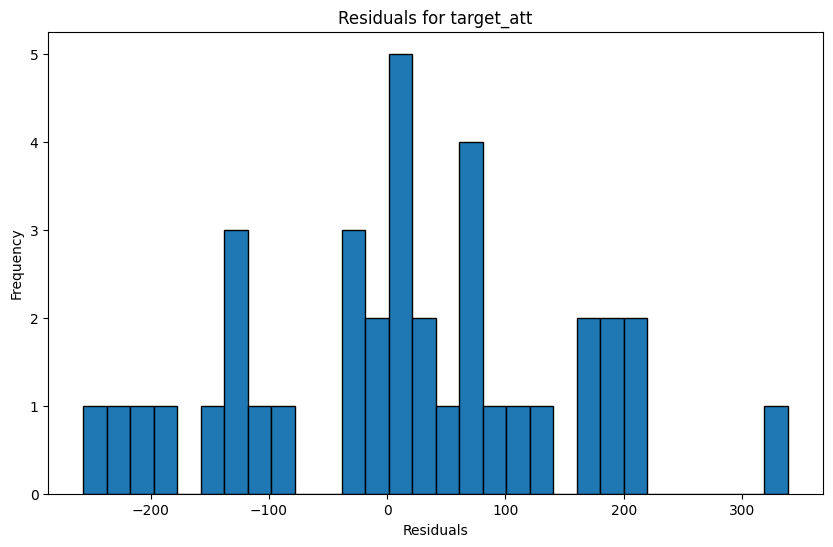

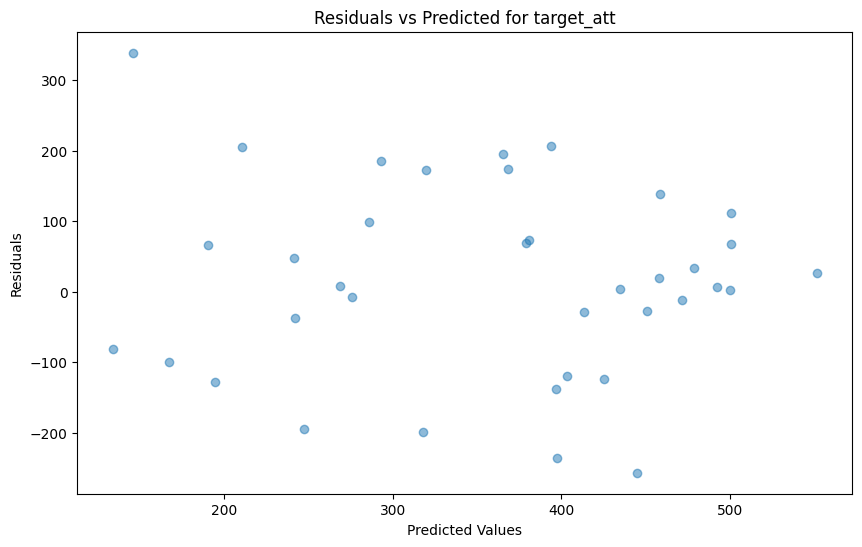

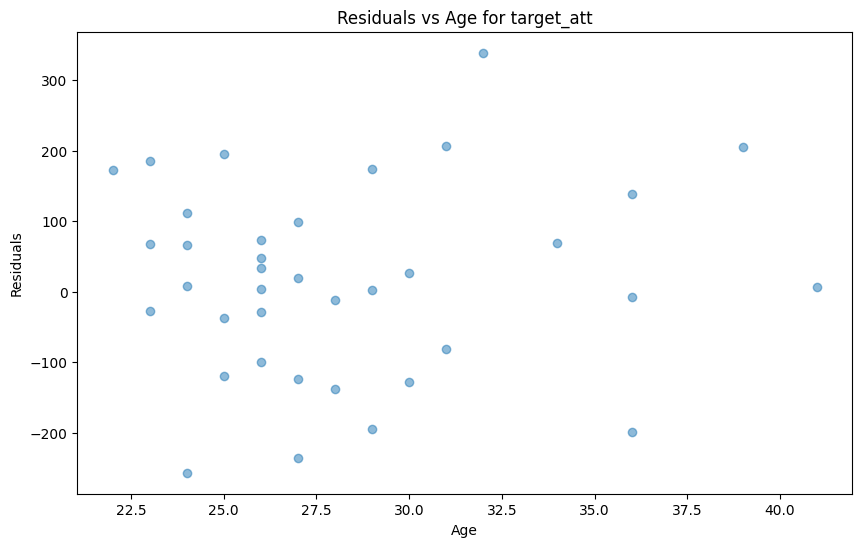

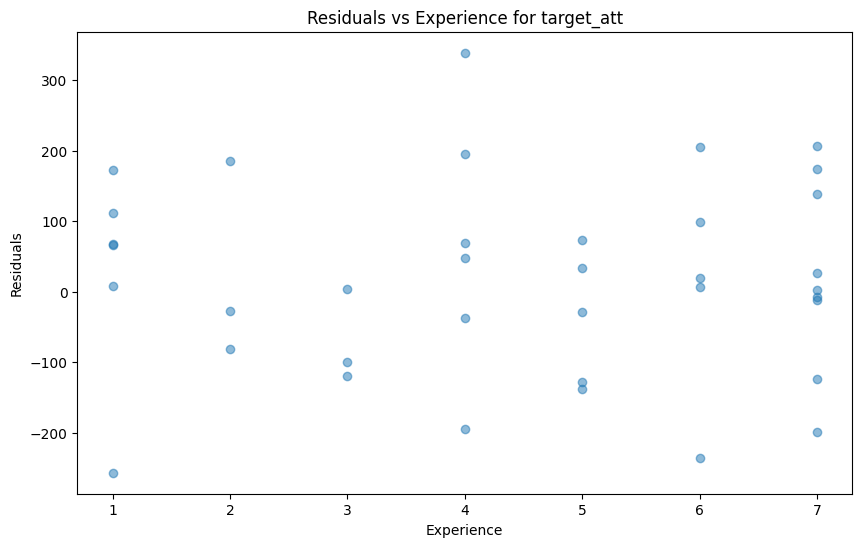

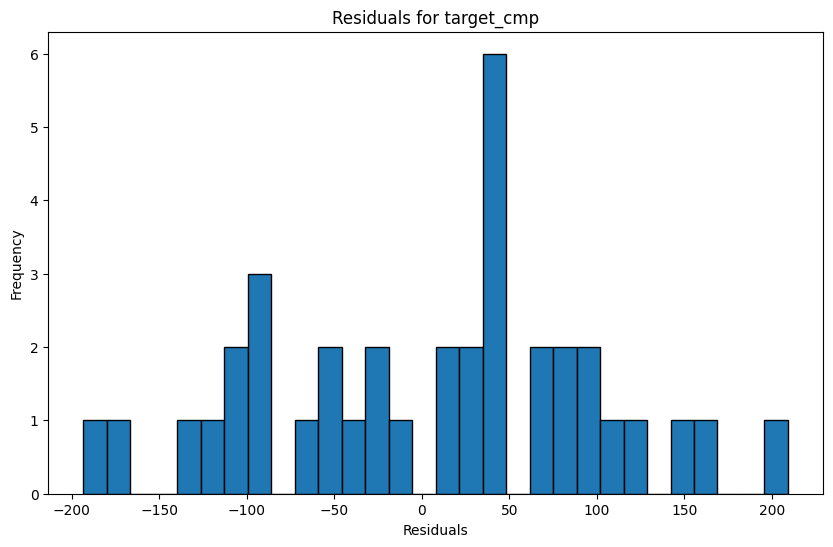

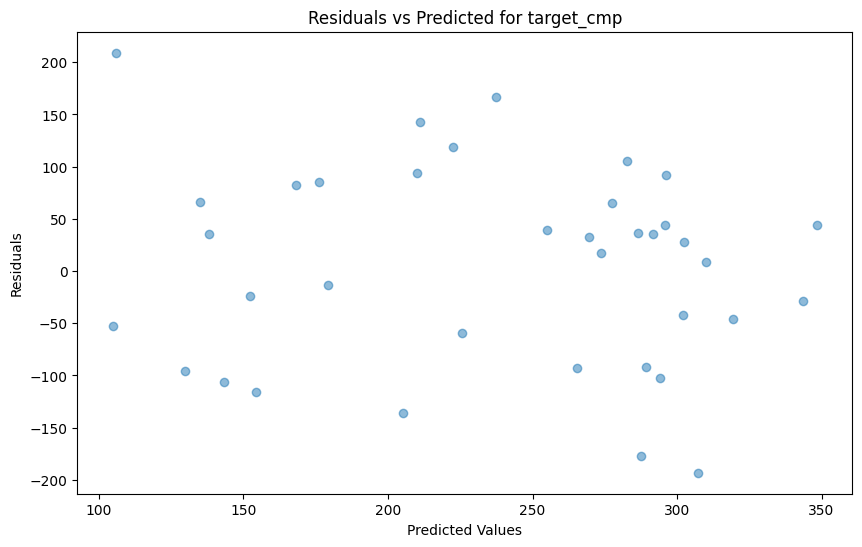

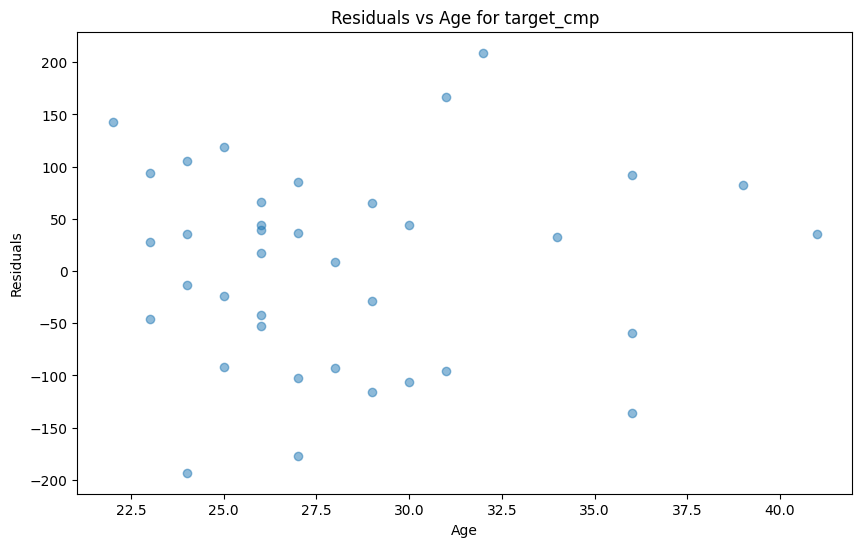

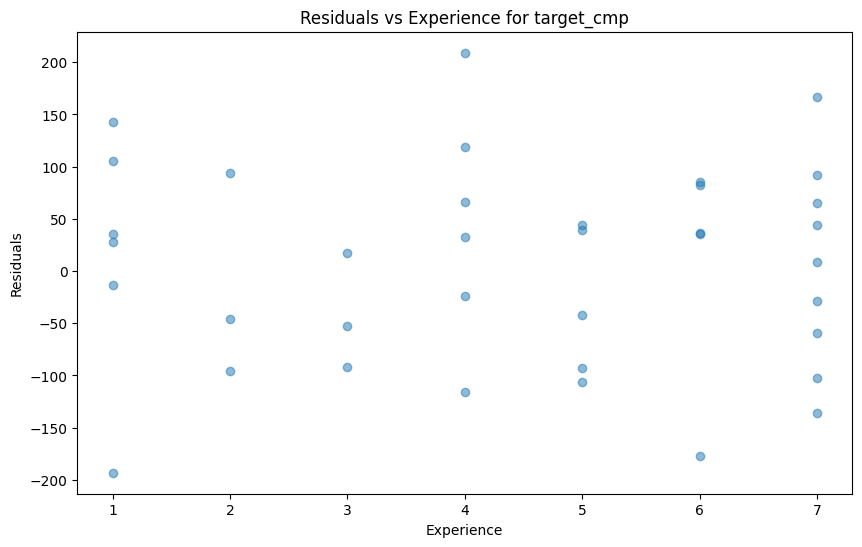

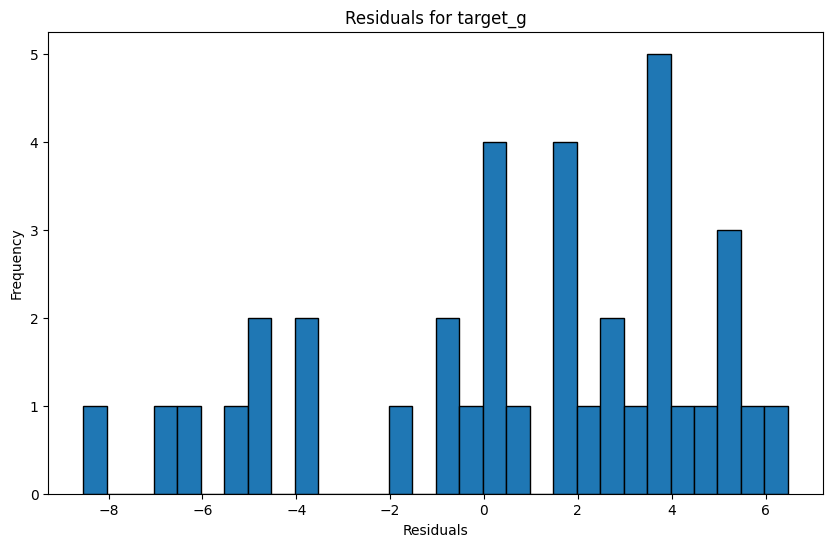

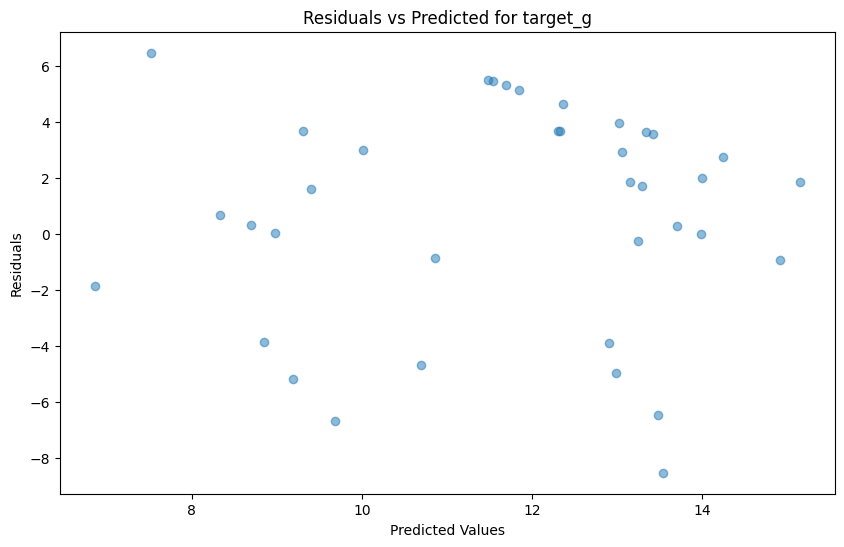

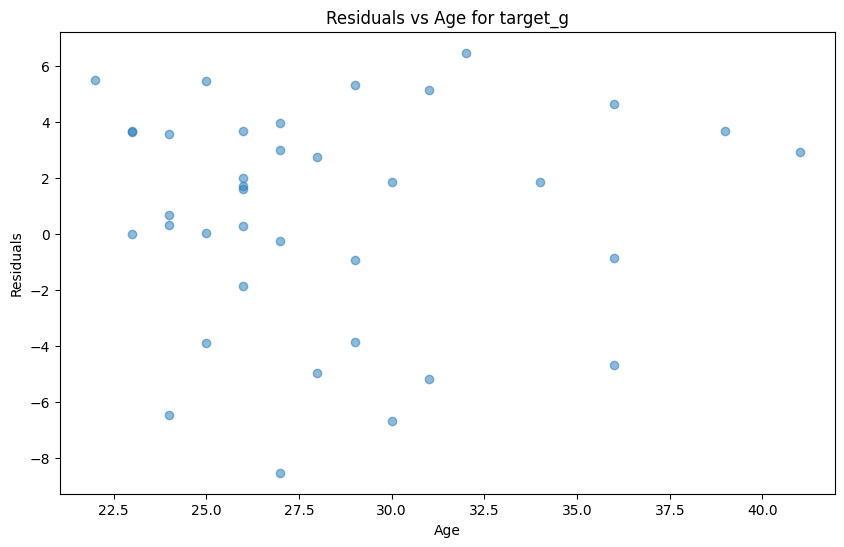

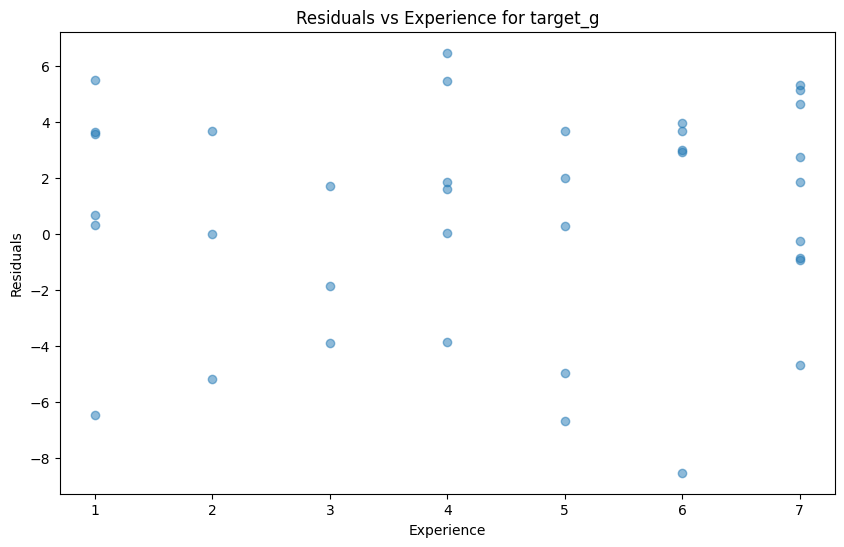

In [12]:
# ─── 11. Residual Analysis ──────────────────────────────────────────
"""
Same residual plots as baseline notebook for consistency
"""

logger.info("Conducting Residual Analysis")

for target in model.target_cols:
    # Calculate residuals
    residuals = df_test_xgboost[target] - predictions_xgboost[target]

    # Plot the residuals as a histogram
    plt.figure(figsize=(10, 6))
    plt.hist(residuals, bins=30, edgecolor='black')
    plt.xlabel('Residuals')
    plt.ylabel('Frequency')
    plt.title(f'Residuals for {target}')
    plt.show()

    # Plot the residuals against the predicted values
    plt.figure(figsize=(10, 6))
    plt.scatter(predictions_xgboost[target], residuals, alpha=0.5)
    plt.xlabel('Predicted Values')
    plt.ylabel('Residuals')
    plt.title(f'Residuals vs Predicted for {target}')
    plt.show()

    # Plot the residuals against the player's age
    plt.figure(figsize=(10, 6))
    plt.scatter(df_test_xgboost['age'], residuals, alpha=0.5)
    plt.xlabel('Age')
    plt.ylabel('Residuals')
    plt.title(f'Residuals vs Age for {target}')
    plt.show()

    # Plot the residuals against the player's experience
    plt.figure(figsize=(10, 6))
    plt.scatter(df_test_xgboost['experience'], residuals, alpha=0.5)
    plt.xlabel('Experience')
    plt.ylabel('Residuals')
    plt.title(f'Residuals vs Experience for {target}')
    plt.show()